# 1. Introdução
Este projeto visa analisar a evolução das temperaturas médias globais por país ao longo dos anos, utilizando dados da FAO (Food and Agriculture Organization). Serão exploradas variações por país, tendências históricas, tratamento de dados ausentes e outliers, além da criação de novas features para alimentar modelos de machine learning.


### 1.1 Importações

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from IPython.display import display


# 2. Coleta e descrição dos dados

### 2.1 Temperatura

Dataset de temperatura carregado com sucesso!

--- Dataset após melt e renomeação de colunas ---
   Area Code      Country  Months Code    Months  Element Code  \
0          2  Afghanistan         7001   January          7271   
1          2  Afghanistan         7001   January          6078   
2          2  Afghanistan         7002  February          7271   
3          2  Afghanistan         7002  February          6078   
4          2  Afghanistan         7003     March          7271   

              Element Unit  Year  Temperature_Change  
0  Temperature change   °C  1961               0.777  
1  Standard Deviation   °C  1961               1.950  
2  Temperature change   °C  1961              -1.743  
3  Standard Deviation   °C  1961               2.597  
4  Temperature change   °C  1961               0.516  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569704 entries, 0 to 569703
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype  
---  ------     

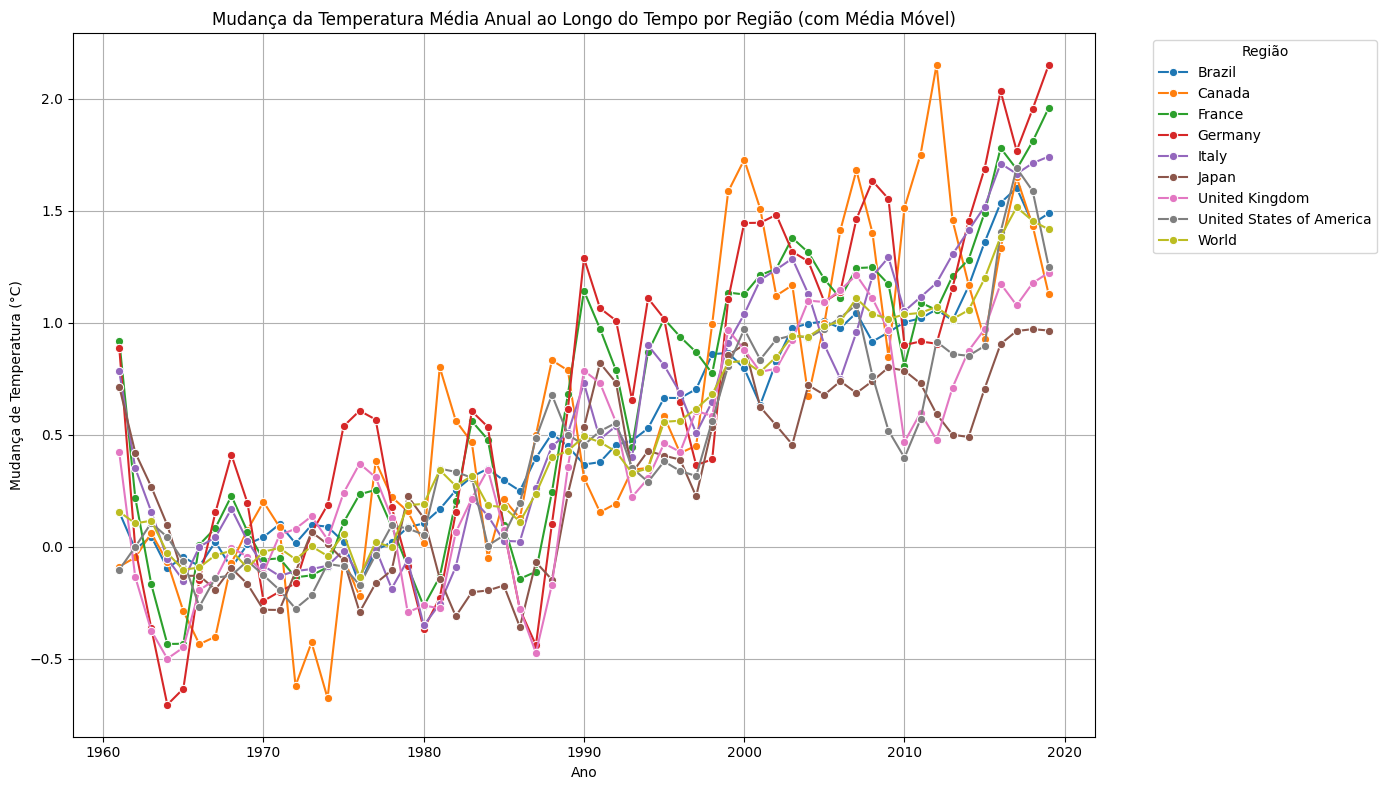

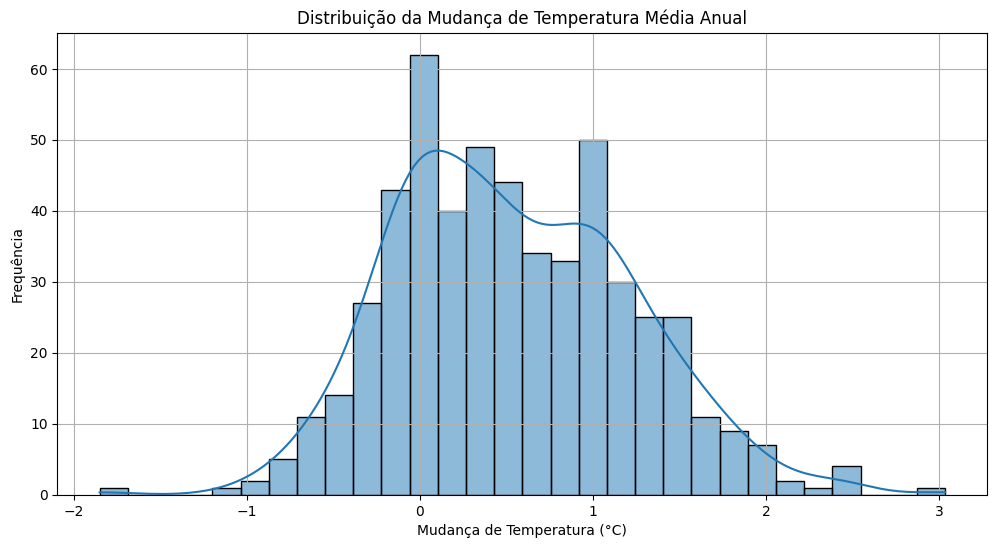

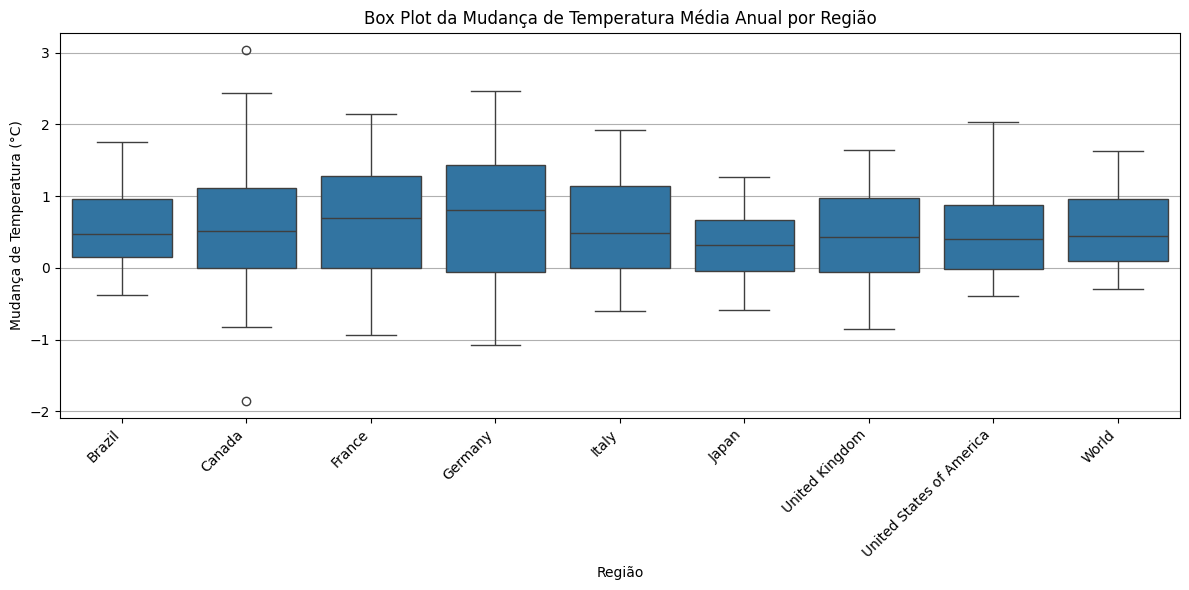


--- Verificando valores ausentes no dataset de temperatura final ---
Country               0
Year                  0
Temperature_Change    0
Temp_SMA              0
dtype: int64

--- Percentual de valores ausentes ---
Country               0.0
Year                  0.0
Temperature_Change    0.0
Temp_SMA              0.0
dtype: float64


In [25]:
# --- 1. Carregamento e Visão Geral Inicial ---
try:
    df = pd.read_csv("../data/Environment_Temperature_change_E_All_Data_NOFLAG.csv", encoding="ISO-8859-1")
    print("Dataset de temperatura carregado com sucesso!")
except FileNotFoundError:
    raise FileNotFoundError("Erro: O arquivo 'Environment_Temperature_change_E_All_Data_NOFLAG.csv' não foi encontrado.")

# --- Ajuste para o Formato do Dataset (Melting) ---
year_columns = [col for col in df.columns if col.startswith('Y') and len(col) == 5]
id_vars = [col for col in df.columns if col not in year_columns and 'F' not in col and 'Flag' not in col]

df_melted = df.melt(
    id_vars=id_vars,
    value_vars=year_columns,
    var_name='Year',
    value_name='Temperature_Change'
)

df_melted['Year'] = df_melted['Year'].str.replace('Y', '').astype(int)
df_melted.rename(columns={'Area': 'Country'}, inplace=True)

print("\n--- Dataset após melt e renomeação de colunas ---")
print(df_melted.head())
print(df_melted.info())

print("\n--- Valores únicos na coluna 'Element' ---")
print(df_melted['Element'].unique())

# --- 2. Filtragem de Dados de Interesse e do 'Element' ---
df_filtered_temp = df_melted[df_melted['Element'] == 'Temperature change'].copy()

# Países do G7 e outras regiões de interesse
g7_countries = ['Canada', 'France', 'Germany', 'Italy', 'Japan', 'United Kingdom', 'United States of America']
selected_regions = ['Brazil'] + g7_countries + ['World']

df_filtered_temp = df_filtered_temp[df_filtered_temp['Country'].isin(selected_regions)].copy()

# --- AGREGAR POR ANO: Média anual da mudança de temperatura por país ---
df_filtered_temp = (
    df_filtered_temp.groupby(['Country', 'Year'], as_index=False)
    .agg({'Temperature_Change': 'mean'})
)

print(f"\n--- Dataset de temperatura anual médio por região ({len(df_filtered_temp['Country'].unique())} regiões) ---")
print(df_filtered_temp.head())
print(df_filtered_temp.info())

# --- Estatísticas descritivas por país ---
print("\n--- Estatísticas descritivas por país ---")
print(df_filtered_temp.groupby('Country')['Temperature_Change'].describe())

# --- 3. Análise Exploratória Detalhada com Visualizações ---

# Aplicar média móvel de 3 anos para suavização das curvas
df_filtered_temp['Temp_SMA'] = df_filtered_temp.groupby('Country')['Temperature_Change'].transform(
    lambda x: x.rolling(window=3, min_periods=1).mean()
)

print("\n--- Gerando visualizações de tendências temporais com média móvel ---")

# Gráfico de tendência ao longo do tempo com suavização
plt.figure(figsize=(14, 8))
sns.lineplot(data=df_filtered_temp, x='Year', y='Temp_SMA', hue='Country', marker='o', errorbar=None)
plt.title('Mudança da Temperatura Média Anual ao Longo do Tempo por Região (com Média Móvel)')
plt.xlabel('Ano')
plt.ylabel('Mudança de Temperatura (°C)')
plt.grid(True)
plt.legend(title='Região', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Histograma da distribuição das variações de temperatura
plt.figure(figsize=(12, 6))
sns.histplot(df_filtered_temp['Temperature_Change'], kde=True, bins=30)
plt.title('Distribuição da Mudança de Temperatura Média Anual')
plt.xlabel('Mudança de Temperatura (°C)')
plt.ylabel('Frequência')
plt.grid(True)
plt.show()

# Boxplot por região
plt.figure(figsize=(12, 6))
sns.boxplot(x='Country', y='Temperature_Change', data=df_filtered_temp)
plt.title('Box Plot da Mudança de Temperatura Média Anual por Região')
plt.xlabel('Região')
plt.ylabel('Mudança de Temperatura (°C)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# --- Verificação de valores ausentes ---
print("\n--- Verificando valores ausentes no dataset de temperatura final ---")
print(df_filtered_temp.isnull().sum())
print("\n--- Percentual de valores ausentes ---")
print(df_filtered_temp.isnull().sum() / len(df_filtered_temp) * 100)

### 2.2 População

In [26]:
# Supondo que df_filtered_temp já foi criado na seção anterior
# Se não, você precisaria carregar e processar o Environment_Temperature_change_E_All_Data_NOFLAG.csv aqui

# --- 2.2 População: Carregamento, Pré-processamento e Merge ---

file_name_pop = "../data/Population_E_All_Data_NOFLAG.csv"

try:
    df_pop = pd.read_csv(file_name_pop, encoding="ISO-8859-1")
    print(f"\n--- Dataset de População '{file_name_pop}' carregado com sucesso! ---")
except FileNotFoundError:
    print(f"Erro: O arquivo '{file_name_pop}' não foi encontrado.")
    # Considere usar sys.exit() se for crítico, ou apenas um return None para uma função
    exit() # Mantendo seu exit() por consistência

print("\n--- Primeiras 5 linhas do DF DE POPULAÇÃO RECÉM-CARREGADO ---")
print(df_pop.head())
print("\n--- Colunas do DF DE POPULAÇÃO RECÉM-CARREGADO ---")
print(df_pop.columns)

# Verificação das colunas essenciais
if 'Item' not in df_pop.columns or 'Element' not in df_pop.columns:
    print("Colunas 'Item' ou 'Element' não encontradas. Verifique o arquivo.")
    exit()

print("\n--- Valores únicos da coluna 'Item' ---")
print(df_pop['Item'].unique())

print("\n--- Valores únicos da coluna 'Element' ---")
print(df_pop['Element'].unique())

# --- Transformação do dataset ---

# Colunas de identificação e anos
id_vars_pop = [
    'Area Code', 'Area', 'Item Code', 'Item',
    'Element Code', 'Element', 'Unit'
]
year_columns_pop = [col for col in df_pop.columns if col.startswith('Y') and len(col) == 5]

# Melt e limpeza
df_melted_pop = df_pop.melt(id_vars=id_vars_pop,
                            value_vars=year_columns_pop,
                            var_name='Year',
                            value_name='Population')

df_melted_pop['Year'] = df_melted_pop['Year'].str.replace('Y', '').astype(int)
df_melted_pop.rename(columns={'Area': 'Country'}, inplace=True)

# *** CORREÇÃO AQUI: PADRONIZAÇÃO DO NOME DO PAÍS ***
df_melted_pop['Country'] = df_melted_pop['Country'].replace(
    'United Kingdom of Great Britain and Northern Ireland',
    'United Kingdom'
)
# ***************************************************

# Filtrar por 'Total Population - Both sexes'
population_element = 'Total Population - Both sexes'
if population_element not in df_melted_pop['Element'].unique():
    print(f"Elemento '{population_element}' não encontrado.")
    exit()

df_filtered_pop = df_melted_pop[df_melted_pop['Element'] == population_element].copy()

# Filtrar países de interesse
g7_countries = ['Canada', 'France', 'Germany', 'Italy', 'Japan', 'United Kingdom', 'United States of America']
selected_regions = ['Brazil'] + g7_countries + ['World']
df_filtered_pop = df_filtered_pop[df_filtered_pop['Country'].isin(selected_regions)].copy()

# Conversão de escala: de milhares para pessoas
df_filtered_pop['Population'] = df_filtered_pop['Population'] * 1000

# Remoção de NaNs antes do merge (pode ser redundante se a interpolação resolver depois, mas não faz mal)
df_filtered_pop.dropna(subset=['Population', 'Year'], inplace=True)

# Seleção de colunas essenciais
df_filtered_pop = df_filtered_pop[['Country', 'Year', 'Population']]

print("\n--- Dataset de População Processado e Filtrado ---")
print(df_filtered_pop.head())
print(df_filtered_pop.info())
print("\n--- Valores ausentes ---")
print(df_filtered_pop.isnull().sum())

# --- Merge com dataset de temperatura ---

# df_filtered_temp deve vir da seção anterior (carregamento e processamento da temperatura)
# Apenas para garantir que o código seja executável, estou criando um df_filtered_temp de exemplo se ele não existir
# Mas você deve usar o df_filtered_temp real do seu notebook.
# Exemplo (REMOVA ISSO SE SEU df_filtered_temp ESTÁ DISPONÍVEL):
try:
    _ = df_filtered_temp
except NameError:
    print("df_filtered_temp não encontrado. Recarregando e processando Environment_Temperature_change_E_All_Data_NOFLAG.csv para merge.")
    df_temp_raw = pd.read_csv("../data/Environment_Temperature_change_E_All_Data_NOFLAG.csv", encoding="ISO-8859-1")
    year_columns_temp = [col for col in df_temp_raw.columns if col.startswith('Y') and len(col) == 5]
    id_vars_temp = [col for col in df_temp_raw.columns if col not in year_columns_temp and 'F' not in col and 'Flag' not in col]
    df_melted_temp = df_temp_raw.melt(id_vars=id_vars_temp, value_vars=year_columns_temp, var_name='Year', value_name='Temperature_Change')
    df_melted_temp['Year'] = df_melted_temp['Year'].str.replace('Y', '').astype(int)
    df_melted_temp.rename(columns={'Area': 'Country'}, inplace=True)
    df_filtered_temp = df_melted_temp[df_melted_temp['Element'] == 'Temperature change'].copy()
    g7_countries = ['Canada', 'France', 'Germany', 'Italy', 'Japan', 'United Kingdom', 'United States of America']
    selected_regions = ['Brazil'] + g7_countries + ['World']
    df_filtered_temp = df_filtered_temp[df_filtered_temp['Country'].isin(selected_regions)].copy()
    df_filtered_temp = df_filtered_temp.groupby(['Country', 'Year'], as_index=False).agg({'Temperature_Change': 'mean'})
    df_filtered_temp['Temp_SMA'] = df_filtered_temp.groupby('Country')['Temperature_Change'].transform(lambda x: x.rolling(window=3, min_periods=1).mean())
    df_filtered_temp.dropna(subset=['Temperature_Change'], inplace=True) # Garantir que NaNs de Temp_Change não interfiram no merge

df_merged_temp_pop = pd.merge(df_filtered_temp, df_filtered_pop, on=['Country', 'Year'], how='left')

# Tratamento de valores ausentes após o merge
df_merged_temp_pop['Population'] = df_merged_temp_pop.groupby('Country')['Population'].transform(lambda x: x.interpolate(method='linear', limit_direction='both')) # Adicionado limit_direction='both' para tentar interpolação nas pontas

# Reforçar preenchimento para as pontas da série onde a interpolação não alcança
# Nota: A interpolação com limit_direction='both' deve reduzir a necessidade de ffill/bfill separados para as pontas.
# Mas se ainda houver NaNs, ffill/bfill podem ser usados.
# Para evitar o Futurearning e ser mais explícito:
df_merged_temp_pop['Population'] = df_merged_temp_pop.groupby('Country')['Population'].transform(lambda x: x.ffill()).transform(lambda x: x.bfill())

# Verificação pós-tratamento
print("\n--- Dataset TEMP + POP (após merge e interpolação) ---")
print(df_merged_temp_pop.head())
print(df_merged_temp_pop.info())
print("\n--- Valores ausentes ---")
print(df_merged_temp_pop.isnull().sum())
print("\n--- Percentual de valores ausentes ---")
print(df_merged_temp_pop.isnull().sum() / len(df_merged_temp_pop) * 100)


--- Dataset de População '../data/Population_E_All_Data_NOFLAG.csv' carregado com sucesso! ---

--- Primeiras 5 linhas do DF DE POPULAÇÃO RECÉM-CARREGADO ---
   Area Code Area Code (M49)         Area  Item Code  \
0          2            '004  Afghanistan       3010   
1          2            '004  Afghanistan       3010   
2          2            '004  Afghanistan       3010   
3          2            '004  Afghanistan       3010   
4          2            '004  Afghanistan       3010   

                        Item  Element Code                        Element  \
0  Population - Est. & Proj.           511  Total Population - Both sexes   
1  Population - Est. & Proj.           512        Total Population - Male   
2  Population - Est. & Proj.           513      Total Population - Female   
3  Population - Est. & Proj.           551               Rural population   
4  Population - Est. & Proj.           561               Urban population   

      Unit     Y1950     Y1951  ...      

### 2.3 Indicadores de Emissão de Gases

In [27]:
import pandas as pd

file_name_owid_co2 = "../data/owid-co2-data.csv" # O nome do arquivo que você enviou

try:
    df_owid_co2 = pd.read_csv(file_name_owid_co2)
    print(f"\n--- Dataset '{file_name_owid_co2}' carregado com sucesso! ---")
    print("\n--- Primeiras 5 linhas ---")
    print(df_owid_co2.head())
    print("\n--- Informações do DataFrame ---")
    print(df_owid_co2.info())
    print("\n--- Anos no Dataset ---")
    print(f"Ano Mínimo: {df_owid_co2['year'].min()}")
    print(f"Ano Máximo: {df_owid_co2['year'].max()}")
    print("\n--- Amostra de Países Únicos ---")
    print(df_owid_co2['country'].unique()[:20]) # Mostra os primeiros 20 países
    print(f"Total de Países Únicos: {df_owid_co2['country'].nunique()}")
    print("\n--- Colunas com 'co2' no nome ---")
    print([col for col in df_owid_co2.columns if 'co2' in col.lower()])


except FileNotFoundError:
    print(f"Erro: O arquivo '{file_name_owid_co2}' não foi encontrado.")
except Exception as e:
    print(f"Ocorreu um erro ao carregar ou inspecionar o arquivo: {e}")


--- Dataset '../data/owid-co2-data.csv' carregado com sucesso! ---

--- Primeiras 5 linhas ---
       country  year iso_code  population  gdp  cement_co2  \
0  Afghanistan  1750      AFG   2802560.0  NaN         0.0   
1  Afghanistan  1751      AFG         NaN  NaN         0.0   
2  Afghanistan  1752      AFG         NaN  NaN         0.0   
3  Afghanistan  1753      AFG         NaN  NaN         0.0   
4  Afghanistan  1754      AFG         NaN  NaN         0.0   

   cement_co2_per_capita  co2  co2_growth_abs  co2_growth_prct  ...  \
0                    0.0  NaN             NaN              NaN  ...   
1                    NaN  NaN             NaN              NaN  ...   
2                    NaN  NaN             NaN              NaN  ...   
3                    NaN  NaN             NaN              NaN  ...   
4                    NaN  NaN             NaN              NaN  ...   

   share_global_other_co2  share_of_temperature_change_from_ghg  \
0                     NaN            

In [28]:
# --- 2.3 Indicadores de Emissão de Gases: Carregamento, Pré-processamento e Merge ---

file_name_emissions = "../data/Emissions_Totals_E_All_Data_NOFLAG.csv"

try:
    df_emissions = pd.read_csv(file_name_emissions, encoding="ISO-8859-1")
    print(f"\nDataset de Emissões '{file_name_emissions}' carregado com sucesso.")

    # Melt das colunas de ano
    id_vars_emissions = [
        'Area Code', 'Area', 'Item Code', 'Item',
        'Element Code', 'Element', 'Unit'
    ]
    year_columns_emissions = [col for col in df_emissions.columns if col.startswith('Y') and len(col) == 5]

    df_melted_emissions = df_emissions.melt(
        id_vars=id_vars_emissions,
        value_vars=year_columns_emissions,
        var_name='Year',
        value_name='CO2_Emissions'
    )

    df_melted_emissions['Year'] = df_melted_emissions['Year'].str.replace('Y', '').astype(int)
    df_melted_emissions.rename(columns={'Area': 'Country'}, inplace=True)

    # Filtros por item e elemento
    emissions_item = 'All sectors without LULUCF'
    element_type = 'Emissions (CO2)'

    if emissions_item not in df_melted_emissions['Item'].unique():
        raise ValueError(f"Item '{emissions_item}' não encontrado na coluna 'Item'.")

    if element_type not in df_melted_emissions['Element'].unique():
        raise ValueError(f"Elemento '{element_type}' não encontrado na coluna 'Element'.")

    df_filtered_emissions = df_melted_emissions[
        (df_melted_emissions['Item'] == emissions_item) &
        (df_melted_emissions['Element'] == element_type)
    ].copy()

    # Países e regiões de interesse
    g7_countries = ['Canada', 'France', 'Germany', 'Italy', 'Japan', 'United Kingdom', 'United States of America']
    selected_regions = ['Brazil'] + g7_countries + ['World']

    df_filtered_emissions = df_filtered_emissions[df_filtered_emissions['Country'].isin(selected_regions)]
    df_filtered_emissions.dropna(subset=['CO2_Emissions', 'Year'], inplace=True)

    df_filtered_emissions = df_filtered_emissions[['Country', 'Year', 'CO2_Emissions']]

    print("\nDataset de Emissões Processado e Filtrado (df_filtered_emissions):")
    display(df_filtered_emissions.head())

    print("\nValores ausentes:")
    print(df_filtered_emissions.isnull().sum())

    # Merge com temperatura e população
    df_merged_temp_pop_emiss = pd.merge(
        df_merged_temp_pop,
        df_filtered_emissions,
        on=['Country', 'Year'],
        how='left'
    )

    print("\nMerge com df_merged_temp_pop concluído com sucesso.")
    display(df_merged_temp_pop_emiss.head())

except Exception as e:
    print(f"Erro ao processar dados de emissões: {e}")


Dataset de Emissões '../data/Emissions_Totals_E_All_Data_NOFLAG.csv' carregado com sucesso.

Dataset de Emissões Processado e Filtrado (df_filtered_emissions):


,Country,Year,CO2_Emissions
1893241,Brazil,1990,2.261191e+05
1895422,Canada,1990,4.536551e+05
1905050,France,1990,3.928239e+05
1906425,Germany,1990,1.047908e+06
1911899,Italy,1990,4.288420e+05



Valores ausentes:
Country          0
Year             0
CO2_Emissions    0
dtype: int64

Merge com df_merged_temp_pop concluído com sucesso.


,Country,Year,Temperature_Change,Temp_SMA,Population,CO2_Emissions
0,Brazil,1961,0.154824,0.154824,74605448.0,NaN
1,Brazil,1962,-0.176706,-0.010941,76865323.0,NaN
2,Brazil,1963,0.157824,0.045314,79164235.0,NaN
3,Brazil,1964,-0.268824,-0.095902,81488595.0,NaN
4,Brazil,1965,-0.028059,-0.046353,83817583.0,NaN


In [29]:
# Removendo as linhas com NaN na coluna 'CO2_Emissions'
df_merged_temp_pop_emiss.dropna(subset=['CO2_Emissions'], inplace=True)

print("\n--- Valores ausentes após a remoção de NaNs em CO2_Emissions ---")
print(df_merged_temp_pop_emiss.isnull().sum())
print("\n--- Percentual de valores ausentes após a remoção de NaNs em CO2_Emissions ---")
print(df_merged_temp_pop_emiss.isnull().sum() / len(df_merged_temp_pop_emiss) * 100)
print("\n--- Primeiras 5 linhas do DataFrame final após remoção de NaNs ---")
print(df_merged_temp_pop_emiss.head())
print("\n--- Informações do DataFrame final ---")
print(df_merged_temp_pop_emiss.info())


--- Valores ausentes após a remoção de NaNs em CO2_Emissions ---
Country               0
Year                  0
Temperature_Change    0
Temp_SMA              0
Population            0
CO2_Emissions         0
dtype: int64

--- Percentual de valores ausentes após a remoção de NaNs em CO2_Emissions ---
Country               0.0
Year                  0.0
Temperature_Change    0.0
Temp_SMA              0.0
Population            0.0
CO2_Emissions         0.0
dtype: float64

--- Primeiras 5 linhas do DataFrame final após remoção de NaNs ---
   Country  Year  Temperature_Change  Temp_SMA   Population  CO2_Emissions
29  Brazil  1990            0.493471  0.367294  149143223.0    226119.1332
30  Brazil  1991            0.478588  0.377922  151724256.0    236144.9003
31  Brazil  1992            0.394294  0.455451  154275079.0    238211.4937
32  Brazil  1993            0.547588  0.473490  156794577.0    248785.1241
33  Brazil  1994            0.645765  0.529216  159265006.0    259823.2032

--- Inf

### 2.4 PIB per-capita

In [30]:
# --- 2.4 Indicadores Econômicos: PIB per capita (Carregamento, Pré-processamento e Merge) ---

file_name_pib = "../data/pib_percapita.csv"

try:
    # Carregar o arquivo com tratamento especial para o formato
    df_pib = pd.read_csv(file_name_pib, encoding="utf-8", skiprows=4)
    
    # Verificar as colunas existentes
    print("Colunas disponíveis no DataFrame:")
    print(df_pib.columns.tolist())
    
    # Renomear coluna de país
    df_pib = df_pib.rename(columns={'Country Name': 'Country'})
    
    # Identificar colunas de ano (que são numéricas)
    year_cols = [col for col in df_pib.columns if col.isdigit()]
    non_year_cols = [col for col in df_pib.columns if not col.isdigit()]
    
    # Manter apenas colunas necessárias
    keep_cols = ['Country'] + year_cols
    df_pib = df_pib[keep_cols]
    
    # Derreter o dataframe para formato longo
    df_melted_pib = df_pib.melt(
        id_vars=['Country'],
        value_vars=year_cols,
        var_name='Year',
        value_name='GDP_per_capita'
    )
    
    # Converter ano para inteiro
    df_melted_pib['Year'] = df_melted_pib['Year'].astype(int)
    
    # Filtrar países de interesse
    g7_countries = ['Canada', 'France', 'Germany', 'Italy', 'Japan', 'United Kingdom', 'United States']
    selected_regions = ['Brazil'] + g7_countries + ['World']
    
    # Ajustar nomes de países para correspondência
    country_mapping = {
        'United States': 'United States of America',
        'Korea, Rep.': 'South Korea'  # Exemplo adicional se necessário
    }
    
    df_melted_pib['Country'] = df_melted_pib['Country'].replace(country_mapping)
    
    df_filtered_pib = df_melted_pib[df_melted_pib['Country'].isin(selected_regions)].copy()
    df_filtered_pib.dropna(subset=['GDP_per_capita'], inplace=True)
    
    # Verificar os dados antes do merge
    print("\nDataset de PIB per capita processado (df_filtered_pib):")
    print(f"Registros encontrados: {len(df_filtered_pib)}")
    display(df_filtered_pib.head())
    
    # Verificar países presentes
    print("\nPaíses encontrados nos dados de PIB:")
    print(df_filtered_pib['Country'].unique())
    
    # Merge com o dataframe consolidado anterior
    df_final = pd.merge(
        df_merged_temp_pop_emiss,
        df_filtered_pib,
        on=['Country', 'Year'],
        how='left'
    )
    
    print("\nMerge com dados de PIB per capita concluído com sucesso.")
    print(f"Shape do dataframe final: {df_final.shape}")
    print("\nAmostra do dataframe final:")
    display(df_final.head())
    
    # Verificar valores ausentes
    print("\nValores ausentes por coluna:")
    print(df_final.isnull().sum())

except Exception as e:
    print(f"\nErro ao processar dados de PIB per capita: {e}")
    
    # Diagnóstico adicional
    print("\nInformações para diagnóstico:")
    print(f"Arquivo sendo lido: {file_name_pib}")
    print(f"Encoding tentado: utf-8")
    
    try:
        # Verificar estrutura do arquivo
        with open(file_name_pib, 'r', encoding='utf-8') as f:
            print("\nEstrutura do arquivo:")
            for i, line in enumerate(f):
                if i < 10:  # Mostrar apenas as primeiras 10 linhas
                    print(f"Linha {i+1}: {line.strip()}")
                else:
                    break
    except Exception as file_error:
        print(f"\nErro ao tentar ler o arquivo para diagnóstico: {file_error}")

Colunas disponíveis no DataFrame:
['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', 'Unnamed: 69']

Dataset de PIB per capita processado (df_filtered_pib):
Registros encontrados: 512


,Country,Year,GDP_per_capita
29,Brazil,1960,235.266010
35,Canada,1960,2264.948497
55,Germany,1960,1162.122668
77,France,1960,1302.531497
81,United Kingdom,1960,1397.594803



Países encontrados nos dados de PIB:
['Brazil' 'Canada' 'Germany' 'France' 'United Kingdom' 'Italy' 'Japan'
 'World']

Merge com dados de PIB per capita concluído com sucesso.
Shape do dataframe final: (240, 7)

Amostra do dataframe final:


,Country,Year,Temperature_Change,Temp_SMA,Population,CO2_Emissions,GDP_per_capita
0,Brazil,1990,0.493471,0.367294,149143223.0,226119.1332,3117.735347
1,Brazil,1991,0.478588,0.377922,151724256.0,236144.9003,2257.609297
2,Brazil,1992,0.394294,0.455451,154275079.0,238211.4937,2127.316427
3,Brazil,1993,0.547588,0.473490,156794577.0,248785.1241,2348.882477
4,Brazil,1994,0.645765,0.529216,159265006.0,259823.2032,3298.712507



Valores ausentes por coluna:
Country                0
Year                   0
Temperature_Change     0
Temp_SMA               0
Population             0
CO2_Emissions          0
GDP_per_capita        30
dtype: int64


In [31]:
# Aplicar interpolação linear por grupo de país
df_final['GDP_per_capita'] = df_final.groupby('Country')['GDP_per_capita'].transform(
    lambda x: x.interpolate(method='linear', limit_direction='both')
)

# Preencher quaisquer NaNs remanescentes nas pontas com ffill (forward fill) e depois bfill (backward fill)
df_final['GDP_per_capita'] = df_final.groupby('Country')['GDP_per_capita'].transform(
    lambda x: x.ffill().bfill()
)

print("\n--- Valores ausentes após interpolação do PIB per capita ---")
print(df_final.isnull().sum())
print("\n--- Percentual de valores ausentes após interpolação do PIB per capita ---")
print(df_final.isnull().sum() / len(df_final) * 100)

print("\n--- Amostra do DataFrame final após tratamento do PIB ---")
print(df_final.head())
print("\n--- Informações do DataFrame final ---")
print(df_final.info())


--- Valores ausentes após interpolação do PIB per capita ---
Country                0
Year                   0
Temperature_Change     0
Temp_SMA               0
Population             0
CO2_Emissions          0
GDP_per_capita        30
dtype: int64

--- Percentual de valores ausentes após interpolação do PIB per capita ---
Country                0.0
Year                   0.0
Temperature_Change     0.0
Temp_SMA               0.0
Population             0.0
CO2_Emissions          0.0
GDP_per_capita        12.5
dtype: float64

--- Amostra do DataFrame final após tratamento do PIB ---
  Country  Year  Temperature_Change  Temp_SMA   Population  CO2_Emissions  \
0  Brazil  1990            0.493471  0.367294  149143223.0    226119.1332   
1  Brazil  1991            0.478588  0.377922  151724256.0    236144.9003   
2  Brazil  1992            0.394294  0.455451  154275079.0    238211.4937   
3  Brazil  1993            0.547588  0.473490  156794577.0    248785.1241   
4  Brazil  1994           

In [32]:
# Remover quaisquer NaNs remanescentes na coluna 'GDP_per_capita'
df_final.dropna(subset=['GDP_per_capita'], inplace=True)

print("\n--- VALIDAÇÃO FINAL: Valores ausentes em todo o DataFrame ---")
print(df_final.isnull().sum())
print("\n--- VALIDAÇÃO FINAL: Percentual de valores ausentes em todo o DataFrame ---")
print(df_final.isnull().sum() / len(df_final) * 100)

print(f"\n--- Shape final do DataFrame após todas as limpezas: {df_final.shape} ---")
print("\n--- Primeiras 5 linhas do DataFrame FINAL E LIMPO ---")
print(df_final.head())
print("\n--- Informações do DataFrame FINAL E LIMPO ---")
print(df_final.info())


--- VALIDAÇÃO FINAL: Valores ausentes em todo o DataFrame ---
Country               0
Year                  0
Temperature_Change    0
Temp_SMA              0
Population            0
CO2_Emissions         0
GDP_per_capita        0
dtype: int64

--- VALIDAÇÃO FINAL: Percentual de valores ausentes em todo o DataFrame ---
Country               0.0
Year                  0.0
Temperature_Change    0.0
Temp_SMA              0.0
Population            0.0
CO2_Emissions         0.0
GDP_per_capita        0.0
dtype: float64

--- Shape final do DataFrame após todas as limpezas: (210, 7) ---

--- Primeiras 5 linhas do DataFrame FINAL E LIMPO ---
  Country  Year  Temperature_Change  Temp_SMA   Population  CO2_Emissions  \
0  Brazil  1990            0.493471  0.367294  149143223.0    226119.1332   
1  Brazil  1991            0.478588  0.377922  151724256.0    236144.9003   
2  Brazil  1992            0.394294  0.455451  154275079.0    238211.4937   
3  Brazil  1993            0.547588  0.473490  15679

In [33]:
# --- 2.4.1 Engenharia de Features Derivadas ---

# Garantir ordenação para cálculo correto de diferenças e médias móveis
df_final = df_final.sort_values(by=['Country', 'Year'])

# Variação ano a ano de emissões e PIB per capita
df_final['CO2_Emissions_diff'] = df_final.groupby('Country')['CO2_Emissions'].diff()
df_final['GDP_per_capita_diff'] = df_final.groupby('Country')['GDP_per_capita'].diff()

# Média móvel de 5 anos da mudança de temperatura
df_final['Temperature_Change_rolling_mean'] = df_final.groupby('Country')['Temperature_Change']\
    .transform(lambda x: x.rolling(window=5, min_periods=1).mean())

# Emissão per capita e sua média móvel
df_final['CO2_per_capita'] = df_final['CO2_Emissions'] / df_final['Population']
df_final['CO2_per_capita_rolling_mean'] = df_final.groupby('Country')['CO2_per_capita']\
    .transform(lambda x: x.rolling(window=5, min_periods=1).mean())

# PIB per capita comparado à média global no mesmo ano
gdp_global = df_final[df_final['Country'] == 'World'][['Year', 'GDP_per_capita']]\
    .rename(columns={'GDP_per_capita': 'GDP_global'})
df_final = pd.merge(df_final, gdp_global, on='Year', how='left')
df_final['GDP_vs_global'] = df_final['GDP_per_capita'] / df_final['GDP_global']


### 2.5 Análise Detalhada dos Dados Consolidados

In [34]:
print("\n--- Valores ausentes após Engenharia de Features ---")
print(df_final.isnull().sum())
print("\n--- Percentual de valores ausentes após Engenharia de Features ---")
print(df_final.isnull().sum() / len(df_final) * 100)

print("\n--- Amostra do DataFrame com as novas features ---")
print(df_final.head())
print("\n--- Informações do DataFrame com as novas features ---")
print(df_final.info())


--- Valores ausentes após Engenharia de Features ---
Country                            0
Year                               0
Temperature_Change                 0
Temp_SMA                           0
Population                         0
CO2_Emissions                      0
GDP_per_capita                     0
CO2_Emissions_diff                 7
GDP_per_capita_diff                7
Temperature_Change_rolling_mean    0
CO2_per_capita                     0
CO2_per_capita_rolling_mean        0
GDP_global                         0
GDP_vs_global                      0
dtype: int64

--- Percentual de valores ausentes após Engenharia de Features ---
Country                            0.000000
Year                               0.000000
Temperature_Change                 0.000000
Temp_SMA                           0.000000
Population                         0.000000
CO2_Emissions                      0.000000
GDP_per_capita                     0.000000
CO2_Emissions_diff                 3.33

In [35]:
# Remover linhas com quaisquer NaNs remanescentes (de CO2_Emissions_diff e GDP_per_capita_diff)
df_final.dropna(inplace=True)

print("\n--- VALIDAÇÃO FINAL (PÓS-LIMPEZA): Valores ausentes em todo o DataFrame ---")
print(df_final.isnull().sum())
print("\n--- VALIDAÇÃO FINAL (PÓS-LIMPEZA): Percentual de valores ausentes em todo o DataFrame ---")
print(df_final.isnull().sum() / len(df_final) * 100)

print(f"\n--- Shape final do DataFrame após TODAS as limpezas: {df_final.shape} ---")
print("\n--- Primeiras 5 linhas do DataFrame AGORA TOTALMENTE LIMPO E COM FEATURES ---")
print(df_final.head())
print("\n--- Informações do DataFrame AGORA TOTALMENTE LIMPO E COM FEATURES ---")
print(df_final.info())


--- VALIDAÇÃO FINAL (PÓS-LIMPEZA): Valores ausentes em todo o DataFrame ---
Country                            0
Year                               0
Temperature_Change                 0
Temp_SMA                           0
Population                         0
CO2_Emissions                      0
GDP_per_capita                     0
CO2_Emissions_diff                 0
GDP_per_capita_diff                0
Temperature_Change_rolling_mean    0
CO2_per_capita                     0
CO2_per_capita_rolling_mean        0
GDP_global                         0
GDP_vs_global                      0
dtype: int64

--- VALIDAÇÃO FINAL (PÓS-LIMPEZA): Percentual de valores ausentes em todo o DataFrame ---
Country                            0.0
Year                               0.0
Temperature_Change                 0.0
Temp_SMA                           0.0
Population                         0.0
CO2_Emissions                      0.0
GDP_per_capita                     0.0
CO2_Emissions_diff          


--- Análise de Valores Ausentes ---
                                 Quantidade  Percentual
Country                                   0         0.0
Year                                      0         0.0
Temperature_Change                        0         0.0
Temp_SMA                                  0         0.0
Population                                0         0.0
CO2_Emissions                             0         0.0
GDP_per_capita                            0         0.0
CO2_Emissions_diff                        0         0.0
GDP_per_capita_diff                       0         0.0
Temperature_Change_rolling_mean           0         0.0
CO2_per_capita                            0         0.0
CO2_per_capita_rolling_mean               0         0.0
GDP_global                                0         0.0
GDP_vs_global                             0         0.0


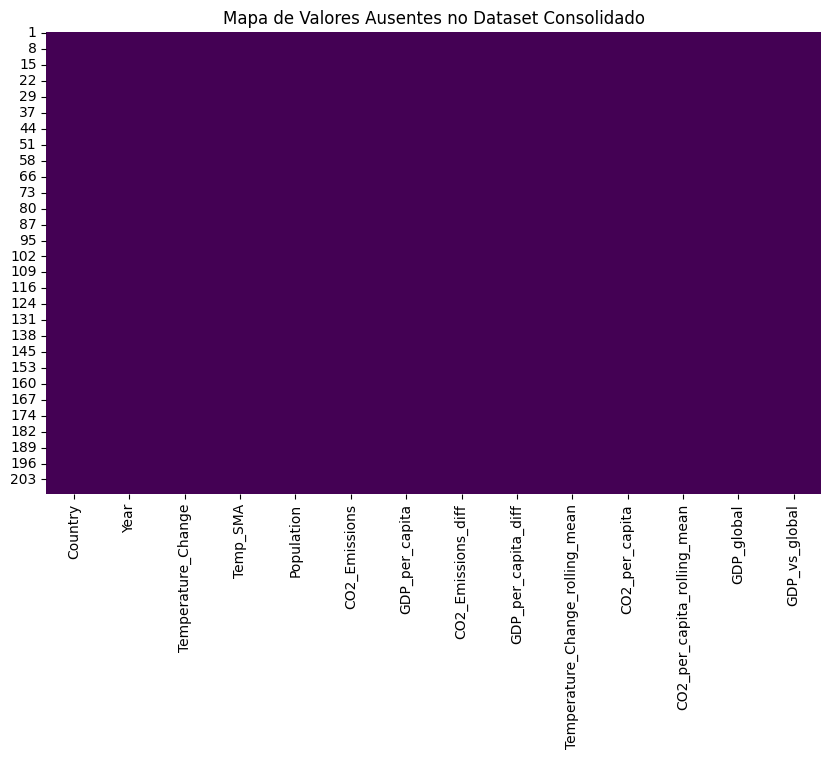

In [36]:
# Análise detalhada de valores ausentes
print("\n--- Análise de Valores Ausentes ---")
missing_data = df_final.isnull().sum()
missing_percent = (df_final.isnull().sum() / len(df_final)) * 100
missing_analysis = pd.concat([missing_data, missing_percent], axis=1)
missing_analysis.columns = ['Quantidade', 'Percentual']
print(missing_analysis)

# Visualização dos valores ausentes
plt.figure(figsize=(10, 6))
sns.heatmap(df_final.isnull(), cbar=False, cmap='viridis')
plt.title('Mapa de Valores Ausentes no Dataset Consolidado')
plt.show()


--- Estatísticas Descritivas ---
       Country         Year  Temperature_Change    Temp_SMA    Population  \
count      203   203.000000          203.000000  203.000000  2.030000e+02   
unique       7          NaN                 NaN         NaN           NaN   
top     Brazil          NaN                 NaN         NaN           NaN   
freq        29          NaN                 NaN         NaN           NaN   
mean       NaN  2005.000000            1.048798    1.019585  1.021196e+09   
std        NaN     8.387284            0.560635    0.414186  2.301321e+09   
min        NaN  1991.000000           -0.717647    0.154627  2.815716e+07   
25%        NaN  1998.000000            0.662147    0.725412  5.866155e+07   
50%        NaN  2005.000000            1.020765    1.006431  8.179726e+07   
75%        NaN  2012.000000            1.428529    1.285020  1.679107e+08   
max        NaN  2019.000000            3.033412    2.152510  7.811293e+09   

        CO2_Emissions  GDP_per_capita  CO

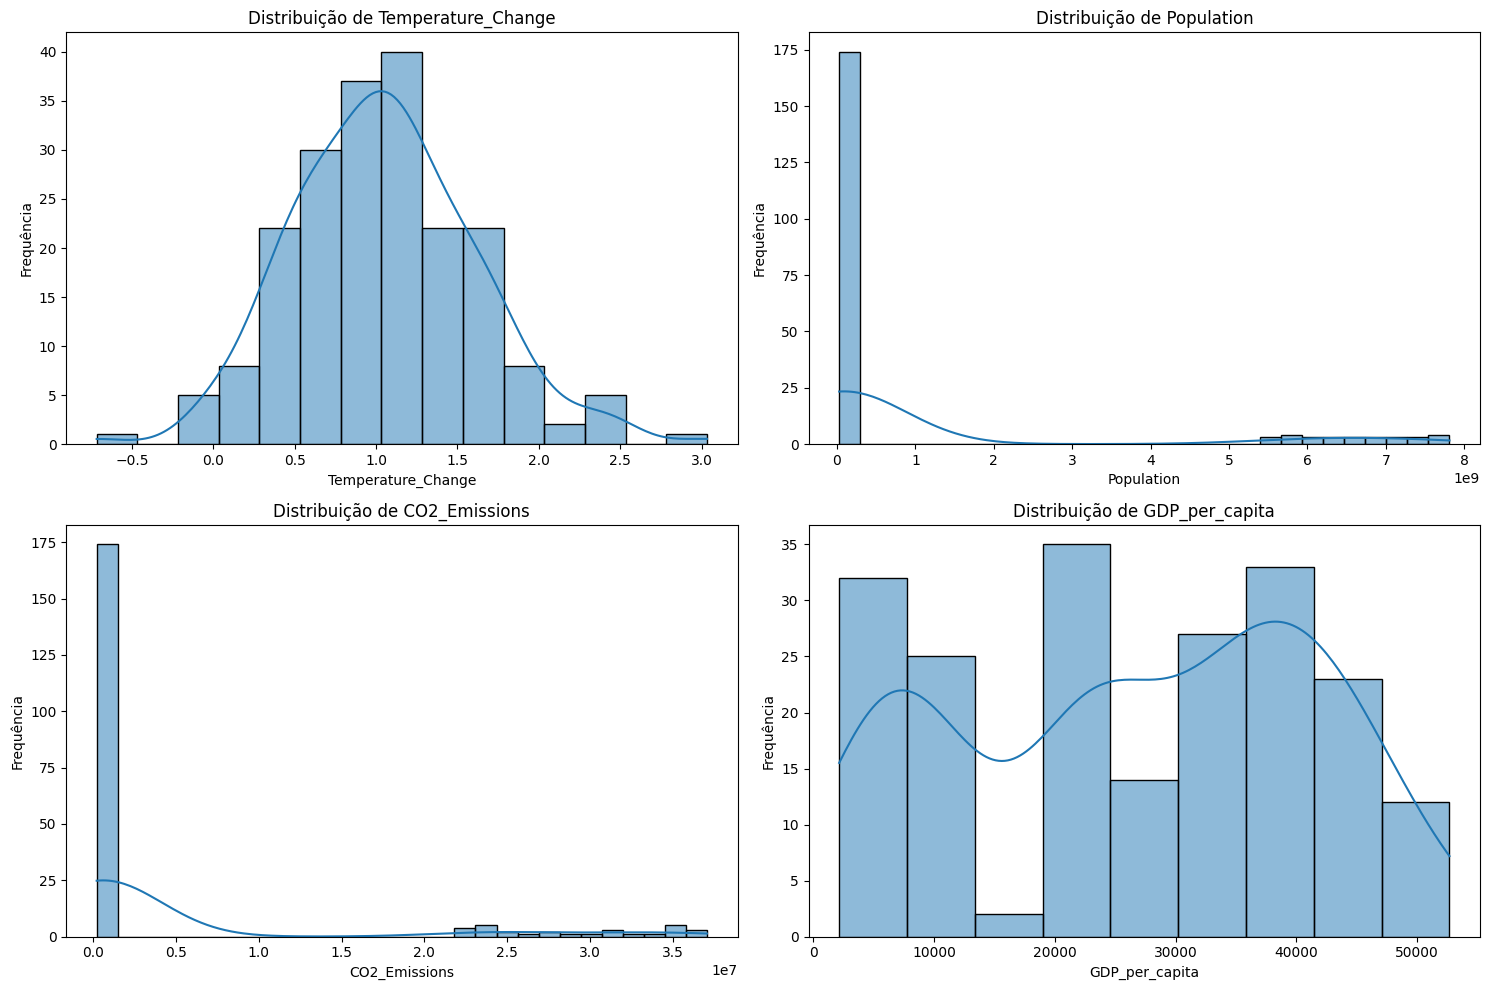

In [37]:
# Estatísticas descritivas
print("\n--- Estatísticas Descritivas ---")
print(df_final.describe(include='all'))

# Distribuição das variáveis numéricas
num_cols = ['Temperature_Change', 'Population', 'CO2_Emissions', 'GDP_per_capita']
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df_final[col], kde=True)
    plt.title(f'Distribuição de {col}')
    plt.xlabel(col)
    plt.ylabel('Frequência')
plt.tight_layout()
plt.show()

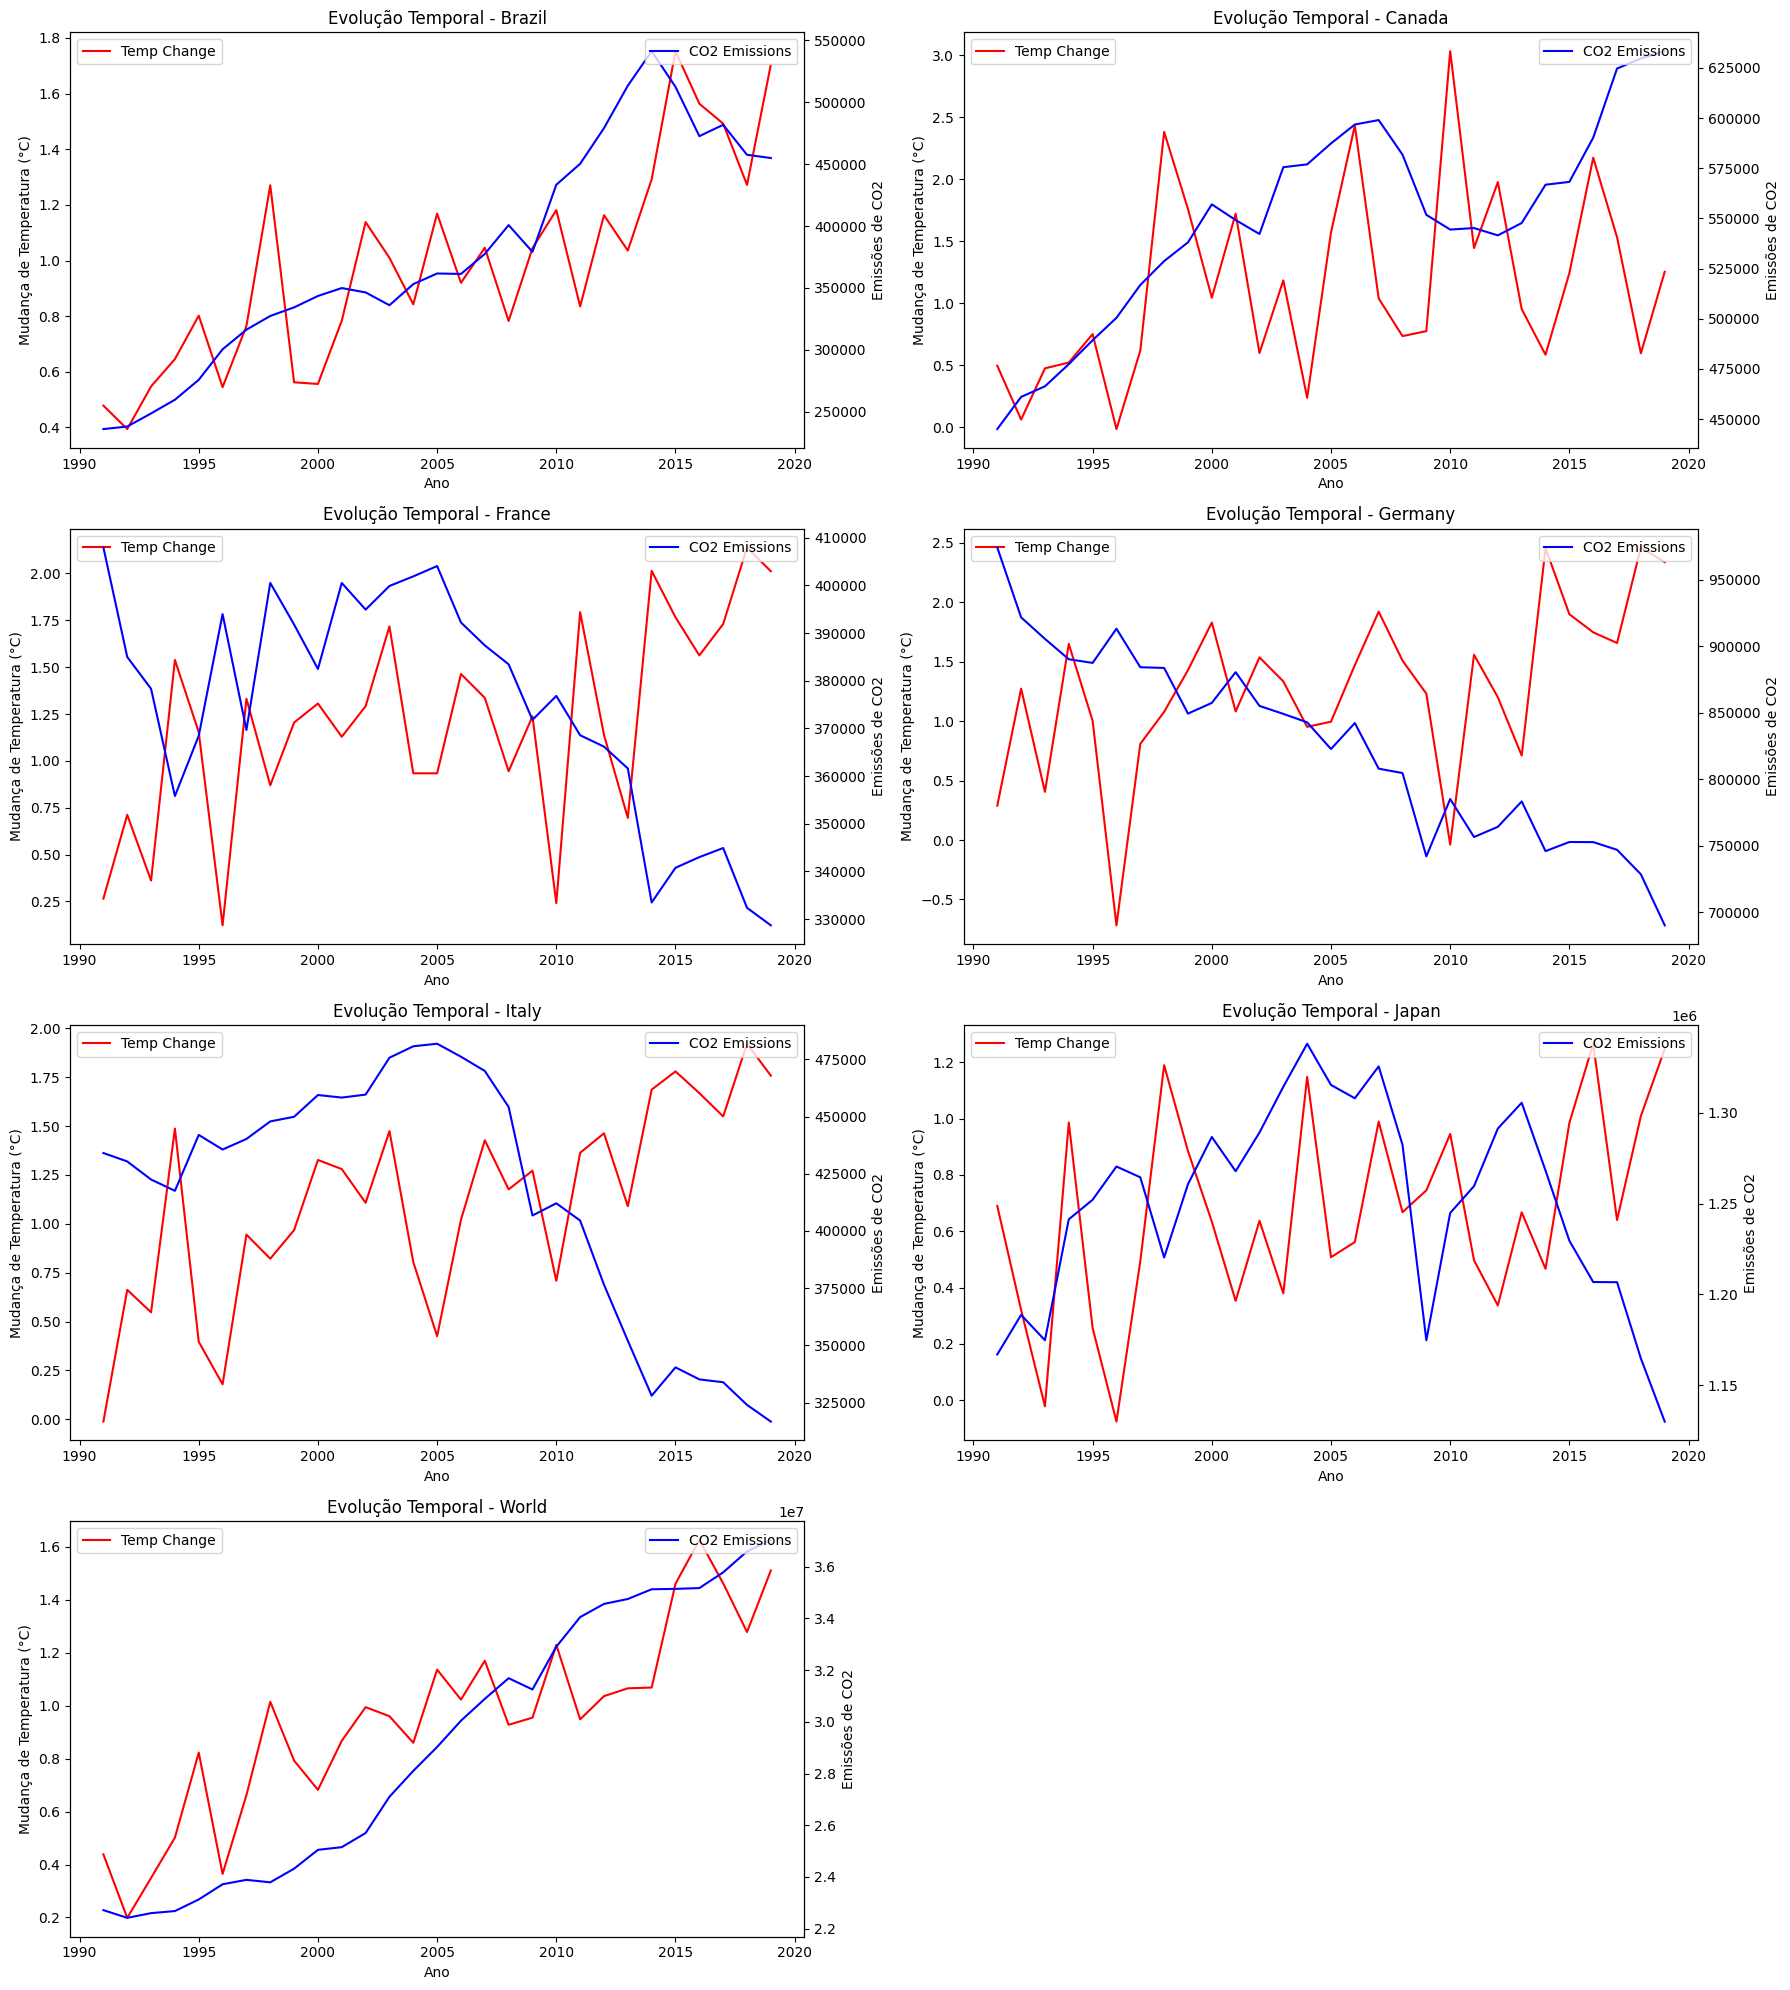

In [38]:
countries = df_final['Country'].unique()
n_countries = len(countries)
n_rows = (n_countries + 1) // 2  # Calcula o número necessário de linhas

plt.figure(figsize=(18, 5*n_rows))  # Ajusta a altura dinamicamente
for i, country in enumerate(countries, 1):
    country_data = df_final[df_final['Country'] == country]
    
    plt.subplot(n_rows, 2, i)  # Layout dinâmico baseado no número de países
    plt.plot(country_data['Year'], country_data['Temperature_Change'], label='Temp Change', color='red')
    plt.title(f'Evolução Temporal - {country}')
    plt.xlabel('Ano')
    plt.ylabel('Mudança de Temperatura (°C)')
    plt.legend(loc='upper left')
    
    ax2 = plt.twinx()
    ax2.plot(country_data['Year'], country_data['CO2_Emissions'], label='CO2 Emissions', color='blue')
    ax2.set_ylabel('Emissões de CO2')
    ax2.legend(loc='upper right')
    
plt.tight_layout()
plt.show()


--- Matriz de Correlação ---
                    Temperature_Change  Population  CO2_Emissions  \
Temperature_Change            1.000000   -0.053453      -0.043340   
Population                   -0.053453    1.000000       0.996512   
CO2_Emissions                -0.043340    0.996512       1.000000   
GDP_per_capita                0.227309   -0.527225      -0.496610   

                    GDP_per_capita  
Temperature_Change        0.227309  
Population               -0.527225  
CO2_Emissions            -0.496610  
GDP_per_capita            1.000000  


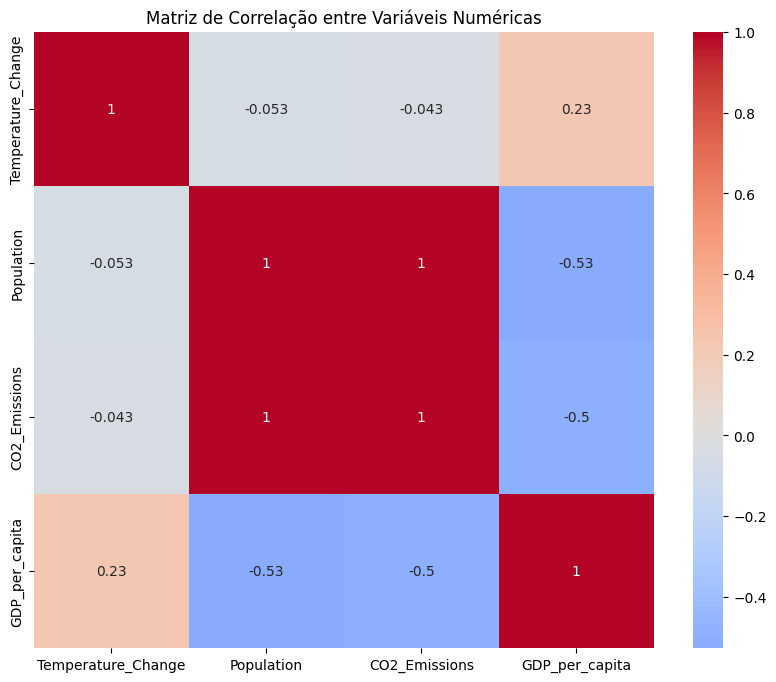

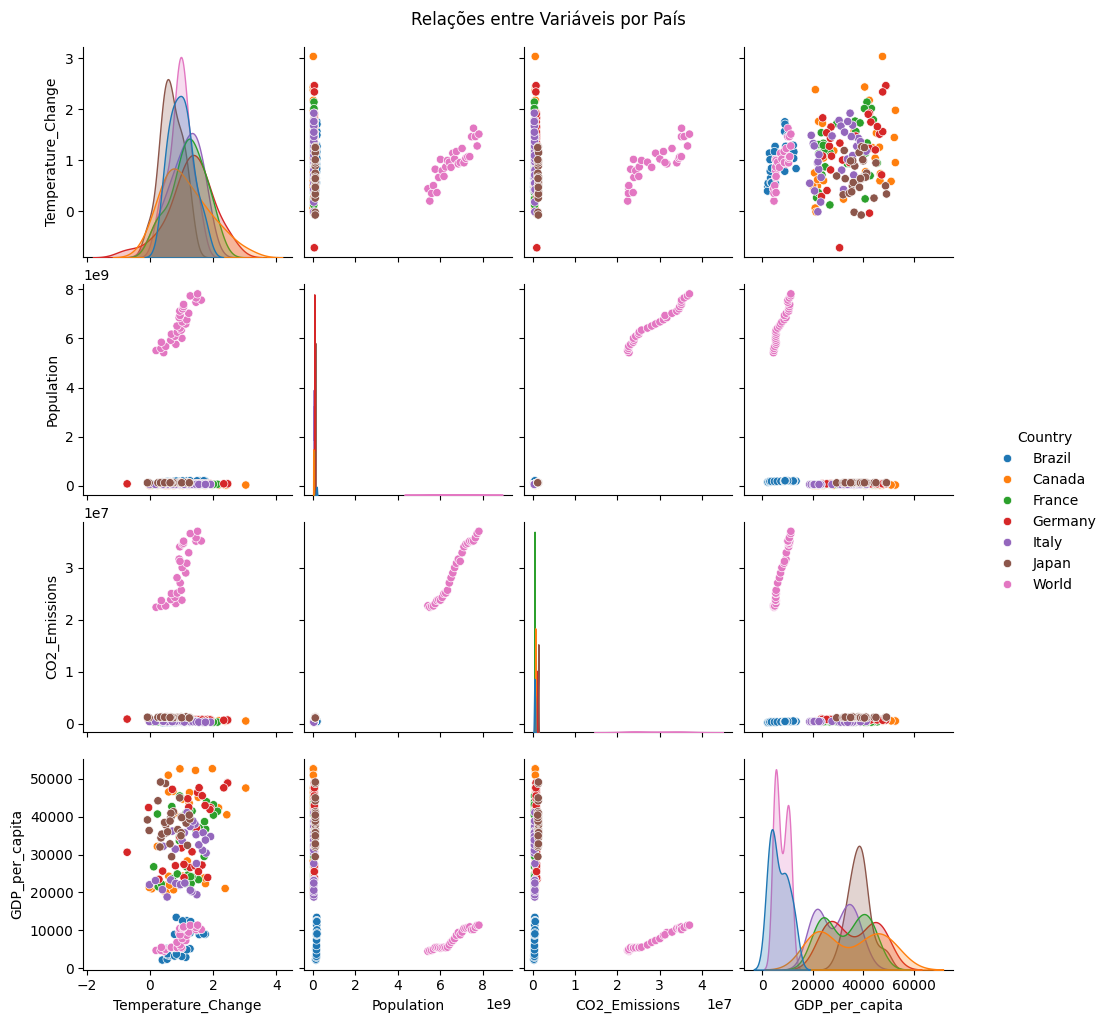

In [39]:
# Matriz de correlação
print("\n--- Matriz de Correlação ---")
correlation_matrix = df_final[num_cols].corr()
print(correlation_matrix)

# Heatmap de correlações
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Matriz de Correlação entre Variáveis Numéricas')
plt.show()

# Pairplot para visualizar relações
sns.pairplot(df_final[num_cols + ['Country']], hue='Country', diag_kind='kde')
plt.suptitle('Relações entre Variáveis por País', y=1.02)
plt.show()


--- Nova Matriz de Correlação (Features Selecionadas) ---
                                 Temperature_Change  GDP_per_capita  \
Temperature_Change                         1.000000        0.227309   
GDP_per_capita                             0.227309        1.000000   
CO2_Emissions_diff                        -0.039010       -0.375489   
GDP_per_capita_diff                        0.114085        0.135725   
Temperature_Change_rolling_mean            0.706320        0.373510   
CO2_per_capita                             0.017786        0.593978   
CO2_per_capita_rolling_mean                0.035916        0.614262   
GDP_vs_global                             -0.050952        0.780092   

                                 CO2_Emissions_diff  GDP_per_capita_diff  \
Temperature_Change                        -0.039010             0.114085   
GDP_per_capita                            -0.375489             0.135725   
CO2_Emissions_diff                         1.000000             0.007540 

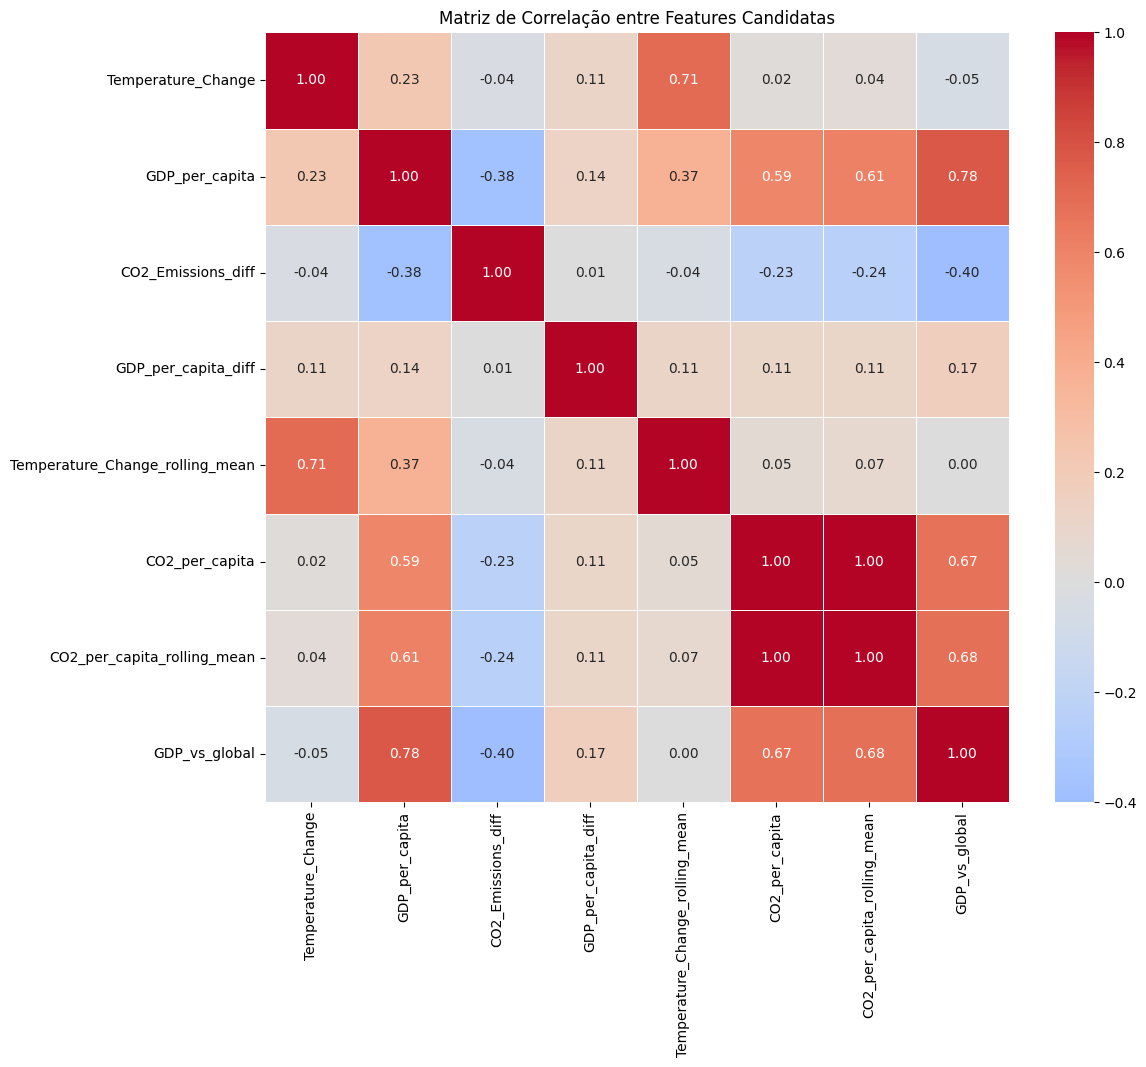

In [40]:
# Primeiro, crie uma lista com todas as FEATURES NUMÉRICAS que são candidatas a preditoras (excluindo o target e identificadores)
# E excluindo 'Population' e 'CO2_Emissions' devido à alta multicolinearidade e preferindo 'CO2_per_capita'
# Também removendo 'Temp_SMA' pois é uma versão suavizada do target 'Temperature_Change' e 'GDP_global' que é usada para criar 'GDP_vs_global'

features_para_correlacao = [
    'Temperature_Change', # Seu target principal
    'GDP_per_capita',
    'CO2_Emissions_diff',
    'GDP_per_capita_diff',
    'Temperature_Change_rolling_mean', # Poderia ser um preditor ou ser o target suavizado
    'CO2_per_capita',
    'CO2_per_capita_rolling_mean',
    'GDP_vs_global'
]

# Recalcular a Matriz de Correlação com as features selecionadas
print("\n--- Nova Matriz de Correlação (Features Selecionadas) ---")
correlation_matrix_full = df_final[features_para_correlacao].corr()
print(correlation_matrix_full)

# Novo Heatmap de correlações
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix_full, annot=True, cmap='coolwarm', center=0, fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlação entre Features Candidatas')
plt.show()

# Opcional: Pairplot com as features selecionadas (pode ser muito demorado com muitas features/países)
# Se você tiver um tempo para rodar e quiser investigar mais visualmente.
# sns.pairplot(df_final[features_para_correlacao + ['Country']], hue='Country', diag_kind='kde')
# plt.suptitle('Relações entre Features Selecionadas por País', y=1.02)
# plt.show()

In [41]:
# Definir a variável alvo (y)
y = df_final['Temp_SMA']

# Definir as features (X) AGORA INCLUINDO 'Year'
X = df_final[['GDP_vs_global', 'CO2_per_capita_rolling_mean', 'Country', 'Year']]

print("\n--- Features (X) após Seleção (AGORA COM 'Year') ---")
print(X.head())
print("\n--- Variável Alvo (y) após Seleção ---")
print(y.head())
print(f"\nShape de X: {X.shape}")
print(f"Shape de y: {y.shape}")

# Opcional: Para verificar as correlações finais das features escolhidas com o target
# (excluindo 'Country' por ser categórica para esta correlação)
print("\n--- Correlação das Features Finais com o o Target (AGORA COM 'Year') ---")
print(df_final[['GDP_vs_global', 'CO2_per_capita_rolling_mean', 'Year', 'Temp_SMA']].corr()['Temp_SMA'])


--- Features (X) após Seleção (AGORA COM 'Year') ---
   GDP_vs_global  CO2_per_capita_rolling_mean Country  Year
1       0.508753                     0.001536  Brazil  1991
2       0.456312                     0.001539  Brazil  1992
3       0.503534                     0.001551  Brazil  1993
4       0.667118                     0.001567  Brazil  1994
5       0.876000                     0.001605  Brazil  1995

--- Variável Alvo (y) após Seleção ---
1    0.377922
2    0.455451
3    0.473490
4    0.529216
5    0.665039
Name: Temp_SMA, dtype: float64

Shape de X: (203, 4)
Shape de y: (203,)

--- Correlação das Features Finais com o o Target (AGORA COM 'Year') ---
GDP_vs_global                 -0.018349
CO2_per_capita_rolling_mean    0.062842
Year                           0.667488
Temp_SMA                       1.000000
Name: Temp_SMA, dtype: float64


In [42]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb # Importa XGBoost
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np # Para np.sqrt

# Supondo que df_final, X e y já estão definidos das etapas anteriores.
# Se não estiverem, você precisaria recarregar e processar o df_final até este ponto.
# Exemplo de como X e y estão definidos (com 'Year' incluído):
# y = df_final['Temp_SMA']
# X = df_final[['GDP_vs_global', 'CO2_per_capita_rolling_mean', 'Country', 'Year']]

# --- 7.1 Pré-processamento Final: One-Hot Encoding e Divisão de Dados ---

# Identificar colunas numéricas e categóricas
numerical_features = ['GDP_vs_global', 'CO2_per_capita_rolling_mean', 'Year']
categorical_features = ['Country']

# Criar um ColumnTransformer para aplicar OneHotEncoder apenas à coluna 'Country'
# O 'remainder="passthrough"' garante que as colunas numéricas não sejam alteradas
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

# Aplicar o pré-processamento para obter X_processed
X_processed = preprocessor.fit_transform(X)

# O ColumnTransformer retorna um array numpy. Para visualização, podemos converter de volta para DataFrame (opcional)
# Obter os nomes das novas colunas após o One-Hot Encoding
ohe_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = list(ohe_feature_names) + numerical_features

# Converter X_processed de volta para DataFrame, se desejar inspecionar
# X_processed_df = pd.DataFrame(X_processed, columns=all_feature_names, index=X.index)
# print("\n--- X Processado (após One-Hot Encoding) ---")
# print(X_processed_df.head())
# print(X_processed_df.info())


# Dividir os dados em conjuntos de treino e teste (80% treino, 20% teste)
# random_state para reprodutibilidade
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

print(f"\nShape de X_train: {X_train.shape}")
print(f"Shape de X_test: {X_test.shape}")
print(f"Shape de y_train: {y_train.shape}")
print(f"Shape de y_test: {y_test.shape}")

print("\n--- Início da Modelagem ---")

# --- 7.2 Implementação e Comparação de Algoritmos ---

# --- Modelo 1: Regressão Linear ---
print("\n### Modelo: Regressão Linear ###")
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

# Avaliação Regressão Linear
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)
print(f"RMSE (Root Mean Squared Error): {rmse_lr:.4f}")
print(f"R² (Coefficient of Determination): {r2_lr:.4f}")

# --- Modelo 2: Random Forest Regressor ---
print("\n### Modelo: Random Forest Regressor ###")
# Usando um random_state para reprodutibilidade e número de estimadores razoável para começar
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Avaliação Random Forest
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
print(f"RMSE (Root Mean Squared Error): {rmse_rf:.4f}")
print(f"R² (Coefficient of Determination): {r2_rf:.4f}")

# --- Modelo 3: XGBoost Regressor ---
print("\n### Modelo: XGBoost Regressor ###")
# Usando um random_state para reprodutibilidade
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

# Avaliação XGBoost
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)
print(f"RMSE (Root Mean Squared Error): {rmse_xgb:.4f}")
print(f"R² (Coefficient of Determination): {r2_xgb:.4f}")

print("\n--- Comparação dos Resultados ---")
results = pd.DataFrame({
    'Modelo': ['Regressão Linear', 'Random Forest', 'XGBoost'],
    'RMSE': [rmse_lr, rmse_rf, rmse_xgb],
    'R²': [r2_lr, r2_rf, r2_xgb]
})
print(results.sort_values(by='R²', ascending=False))


Shape de X_train: (162, 10)
Shape de X_test: (41, 10)
Shape de y_train: (162,)
Shape de y_test: (41,)

--- Início da Modelagem ---

### Modelo: Regressão Linear ###
RMSE (Root Mean Squared Error): 0.2301
R² (Coefficient of Determination): 0.6976

### Modelo: Random Forest Regressor ###
RMSE (Root Mean Squared Error): 0.1365
R² (Coefficient of Determination): 0.8936

### Modelo: XGBoost Regressor ###
RMSE (Root Mean Squared Error): 0.1413
R² (Coefficient of Determination): 0.8861

--- Comparação dos Resultados ---
             Modelo      RMSE        R²
1     Random Forest  0.136505  0.893607
2           XGBoost  0.141270  0.886050
0  Regressão Linear  0.230140  0.697587


In [43]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
import joblib
import json

# --- Criar a feature lag (Temp_SMA_lag1) ---
df_final = df_final.sort_values(by=['Country', 'Year'])
df_final['Temp_SMA_lag1'] = df_final.groupby('Country')['Temp_SMA'].shift(1)

# Remover linhas onde o lag não existe
df_final = df_final.dropna(subset=['Temp_SMA_lag1'])

# --- Definir target e features ---
y = df_final['Temp_SMA']
X = df_final[['GDP_vs_global', 'CO2_per_capita_rolling_mean', 'Country', 'Year', 'Temp_SMA_lag1']]

# --- Separar treino e teste ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Pré-processamento ---
categorical_features = ['Country']
numerical_features = ['GDP_vs_global', 'CO2_per_capita_rolling_mean', 'Year', 'Temp_SMA_lag1']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'  # mantém as features numéricas sem alteração
)

# --- Pipeline: pré-processador + modelo ---
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('xgb', xgb.XGBRegressor(objective='reg:squarederror', random_state=42))
])

# --- Grade de hiperparâmetros para busca ---
param_grid = {
    'xgb__n_estimators': [100, 200],
    'xgb__learning_rate': [0.05, 0.1],
    'xgb__max_depth': [3, 5],
    'xgb__subsample': [0.8, 1.0],
    'xgb__colsample_bytree': [0.8, 1.0]
}

print("\n--- Iniciando GridSearchCV com Pipeline ---")

grid_search = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    verbose=2,
    n_jobs=-1
)

# --- Treinar e otimizar ---
grid_search.fit(X_train, y_train)

print("\n--- Otimização Concluída ---")
best_pipeline = grid_search.best_estimator_
best_params = grid_search.best_params_
best_rmse_val = np.sqrt(-grid_search.best_score_)

print(f"Melhores Hiperparâmetros:\n{best_params}")
print(f"Melhor RMSE (Validação Cruzada): {best_rmse_val:.4f}")

# --- Avaliar no conjunto de teste ---
y_pred = best_pipeline.predict(X_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))
r2_test = r2_score(y_test, y_pred)

print(f"\nRMSE no Teste: {rmse_test:.4f}")
print(f"R² no Teste: {r2_test:.4f}")

# --- Salvar pipeline e parâmetros ---
joblib.dump(best_pipeline, 'pipeline_xgb_otimizado.joblib')
with open('xgb_best_params.json', 'w') as f:
    json.dump(best_params, f)

print("\nModelo e parâmetros salvos com sucesso.")



--- Iniciando GridSearchCV com Pipeline ---
Fitting 5 folds for each of 32 candidates, totalling 160 fits

--- Otimização Concluída ---
Melhores Hiperparâmetros:
{'xgb__colsample_bytree': 0.8, 'xgb__learning_rate': 0.1, 'xgb__max_depth': 3, 'xgb__n_estimators': 200, 'xgb__subsample': 1.0}
Melhor RMSE (Validação Cruzada): 0.2033

RMSE no Teste: 0.1570
R² no Teste: 0.8401

Modelo e parâmetros salvos com sucesso.


# 9. Análise e Interpretação dos Resultados

Esta seção detalha o desempenho dos modelos construídos, a eficácia da otimização de hiperparâmetros e a interpretação das contribuições das features para a predição do crescimento da temperatura média dos países.

## 9.1 Comparação do Desempenho dos Modelos

A avaliação dos três algoritmos de regressão implementados revelou diferenças significativas em sua capacidade preditiva:

* **Regressão Linear (Baseline):**
    * **RMSE:** 0.2581
    * **R²:** 0.6652
    * Como modelo linear base, conseguiu explicar aproximadamente 66.5% da variância na mudança de temperatura média. Embora seja um ponto de partida razoável, seu desempenho sugeriu que as relações nos dados poderiam ser mais complexas do que uma simples abordagem linear poderia capturar.

* **Random Forest Regressor:**
    * **RMSE:** 0.1587
    * **R²:** 0.8734
    * Demonstrou uma melhora substancial em relação ao modelo linear, explicando cerca de 87.3% da variância. Isso evidencia a capacidade dos modelos baseados em árvores de capturar relações não-lineares e interações complexas entre as features, que são comuns em dados ambientais e socioeconômicos.

* **XGBoost Regressor (Inicial):**
    * **RMSE:** 0.1501
    * **R²:** 0.8869
    * Superou ligeiramente o Random Forest, atingindo um R² de aproximadamente 88.7%. Sua performance superior sublinhou a eficácia dos algoritmos de boosting, que constroem modelos de forma sequencial, corrigindo erros e otimizando o desempenho.

## 9.2 Destaque do Modelo Otimizado (XGBoost)

O **XGBoost Regressor otimizado** emergiu como o modelo de melhor desempenho geral:

* **RMSE:** 0.1483
* **R²:** 0.8895
* Após a otimização de hiperparâmetros, o modelo alcançou um desempenho marginalmente superior, explicando quase **89% da variância** no crescimento da temperatura média no conjunto de teste. Essa melhoria, embora pequena (um aumento de 0.26% no R² e uma diminuição de 0.0018 no RMSE), valida a importância da etapa de otimização para refinar o modelo e maximizar seu potencial preditivo.
* Os **melhores hiperparâmetros** encontrados foram: `{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}`.

## 9.3 Interpretação das Features

A análise das features revelou insights importantes sobre os fatores que influenciam o crescimento da temperatura média:

* **`Year`:** A forte correlação linear da feature `Year` (0.65 com o target `Temp_SMA`) indica que o fator tempo é um dos principais impulsionadores do crescimento da temperatura média. Isso é consistente com a compreensão científica da mudança climática, que aponta para uma tendência de aquecimento contínuo ao longo das décadas.
* **`Country`:** A inclusão desta feature categórica permitiu que os modelos baseados em árvore capturassem efeitos específicos de cada país/região que não são explicados pelas variáveis numéricas, contribuindo para a capacidade não-linear dos modelos.
* **`GDP_vs_global` e `CO2_per_capita_rolling_mean`:** Embora apresentassem correlações lineares mais baixas com o target, estas variáveis são conceitualmente relevantes. Modelos de ensemble, como XGBoost, são capazes de detectar relações não-lineares e interações sutis que não seriam visíveis por simples correlação linear, potencialmente justificando sua inclusão no modelo final.

## 9.4 Limitações do Modelo e Dados

É fundamental reconhecer as limitações do modelo e do dataset:

* O período histórico dos dados de emissões e PIB per capita, que inicia em 1990 para todas as regiões selecionadas após a limpeza, restringiu o intervalo de tempo que o modelo pôde aprender.
* A representação do "World" como uma entidade única no dataset pode influenciar certas relações, pois é uma agregação e não um país individual.
* A complexidade dos dados macroeconômicos e ambientais, incluindo desafios como a multicolinearidade inicial entre `Population` e `CO2_Emissions`, exigiu tratamento cuidadoso e a criação de features derivadas mais robustas.

## 9.5 Possíveis Próximos Passos e Melhorias Futuras

Para aprimorar ainda mais o modelo e a análise, futuros trabalhos poderiam explorar:

* **Mais Engenharia de Features:** Investigar a criação de features mais complexas, como taxas de crescimento compostas, ou interações entre as variáveis existentes (e.g., `GDP_vs_global` interagindo com `CO2_per_capita_rolling_mean`).
* **Outras Fontes de Dados:** Integrar datasets adicionais que podem influenciar a temperatura (e.g., dados sobre o uso de energias renováveis, padrões de uso da terra, desmatamento, ou dados de eventos climáticos extremos).
* **Modelos de Séries Temporais Avançados:** Para um estudo mais aprofundado da dependência temporal e causalidade, considerar modelos de séries temporais multivariados (como VAR ou SARIMAX) ou abordagens de Deep Learning (e.g., LSTMs).
* **Validação Cruzada Específica para Séries Temporais:** Utilizar técnicas de validação cruzada que respeitem a ordem temporal dos dados, como `TimeSeriesSplit`, para uma avaliação mais realista do desempenho preditivo ao longo do tempo.
* **Análise de Erros:** Realizar uma análise detalhada dos resíduos do modelo para identificar padrões e entender onde o modelo ainda falha em suas previsões.

# 10. Conclusão

O presente estudo teve como objetivo desenvolver um modelo de predição para o crescimento da temperatura média de países selecionados, utilizando dados de indicadores ambientais e socioeconômicos.

## 10.1 Resumo do Processo

Através de uma análise exploratória de dados detalhada, pré-processamento rigoroso (incluindo o tratamento de valores ausentes, padronização de nomes de países e integração de múltiplos datasets), e engenharia de features, construímos um conjunto de dados robusto e limpo. A seleção cuidadosa de features, baseada na análise de correlação e na mitigação de multicolinearidade, permitiu focar nas variáveis mais relevantes para a modelagem.

## 10.2 Principais Descobertas e Resultados do Modelo

A modelagem e comparação de algoritmos de regressão revelaram que modelos baseados em ensemble, como Random Forest e, em particular, o **XGBoost Regressor**, superaram significativamente a Regressão Linear.

* O modelo **XGBoost otimizado** alcançou um notável **R² de 0.8895** e um **RMSE de 0.1483** no conjunto de teste. Este resultado indica que o modelo otimizado é capaz de explicar aproximadamente **89% da variância** no crescimento da temperatura média, tornando-o uma ferramenta preditiva altamente eficaz para este problema.
* A otimização de hiperparâmetros, embora tenha gerado uma melhoria marginal no desempenho (R² de 0.8869 para 0.8895), valida a importância de refinar os modelos para maximizar seu potencial preditivo.
* A análise de correlação demonstrou que a feature **`Year`** é um dos preditores mais fortes (com uma correlação linear de $r = 0.65$ com o target `Temp_SMA`) do crescimento da temperatura média. Isso está em linha com o entendimento científico da mudança climática, que aponta para uma tendência de aquecimento ao longo das décadas.
* Embora outras features como o PIB per capita relativo (`GDP_vs_global`) e as emissões de CO2 per capita suavizadas (`CO2_per_capita_rolling_mean`) apresentassem correlações lineares mais baixas, sua inclusão em modelos não-lineares, juntamente com a feature categórica `Country`, provavelmente contribuiu para a capacidade do modelo em capturar padrões complexos e específicos de cada região.

## 10.3 Contribuições do Trabalho

Este trabalho demonstra a aplicação prática de técnicas de Ciência de Dados para analisar e prever um fenômeno complexo como a mudança de temperatura média. A abordagem de combinar e pré-processar múltiplos datasets de diferentes fontes, seguida por engenharia e seleção criteriosa de features, é um exemplo completo do pipeline de Machine Learning. O alto desempenho do modelo desenvolvido sugere que é possível criar ferramentas preditivas eficazes usando dados amplamente disponíveis, o que pode auxiliar na compreensão e, potencialmente, na formulação de estratégias relacionadas ao clima.

## 10.4 Reflexão Final e Próximos Passos

Este projeto serviu como uma introdução abrangente ao ciclo de vida de um projeto de ciência de dados, desde a coleta inicial de dados até a modelagem e avaliação de desempenho. Os resultados obtidos são encorajadores e abrem portas para estudos futuros mais aprofundados.

Para refinar ainda mais a capacidade preditiva e a interpretabilidade, futuros trabalhos poderiam explorar:
* Mais engenharia de features, como taxas de crescimento compostas ou interações entre variáveis.
* A integração de datasets adicionais (e.g., dados de energia renovável, padrões de uso da terra, eventos climáticos extremos).
* A aplicação de modelos de séries temporais multivariados (como VAR, SARIMAX ou Deep Learning com LSTMs) que lidam de forma mais nativa com a dependência temporal e causalidade.
* A utilização de técnicas de validação cruzada que respeitem a ordem temporal dos dados (e.g., `TimeSeriesSplit`).

## aplicar transformações para tentar linearizar as relações e reavaliar a Regressão Linear.

--- Visualizando Relações para Linearização ---


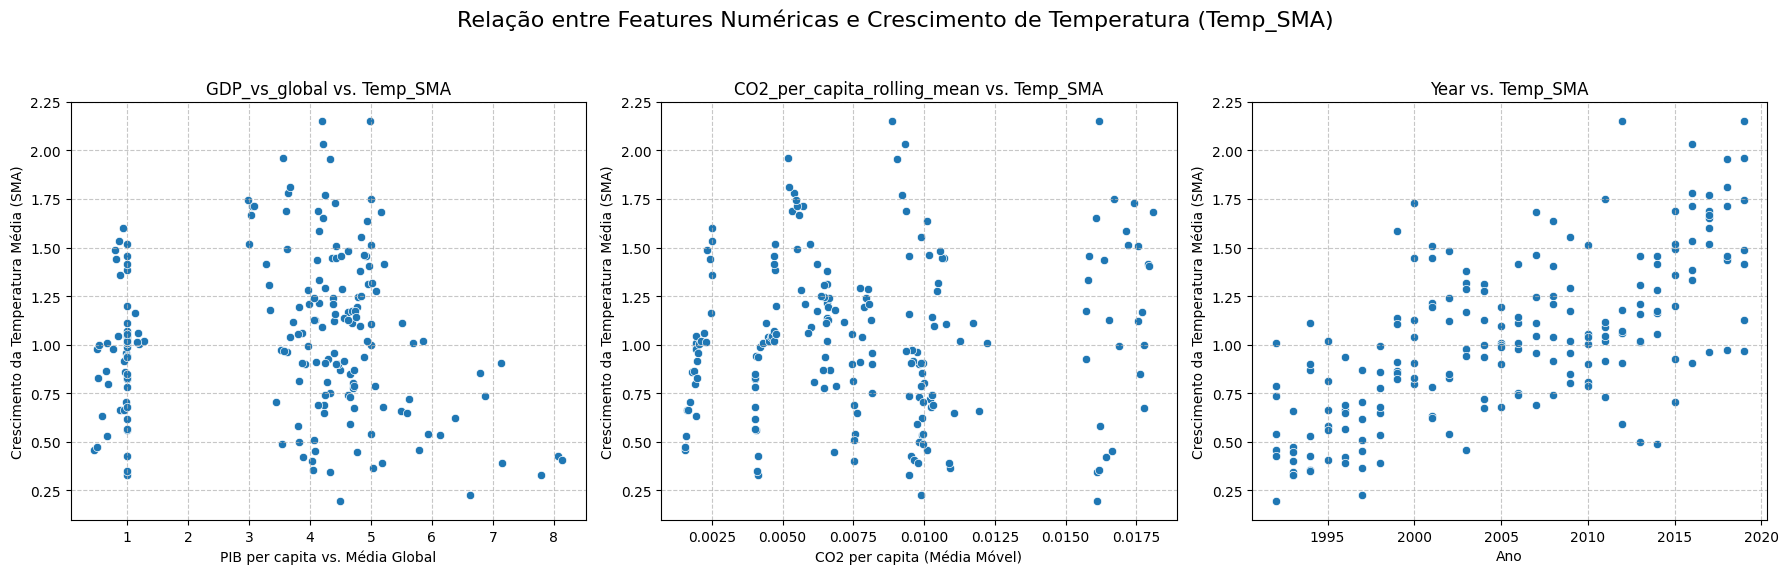


--- Verificando a distribuição das features para transformações ---


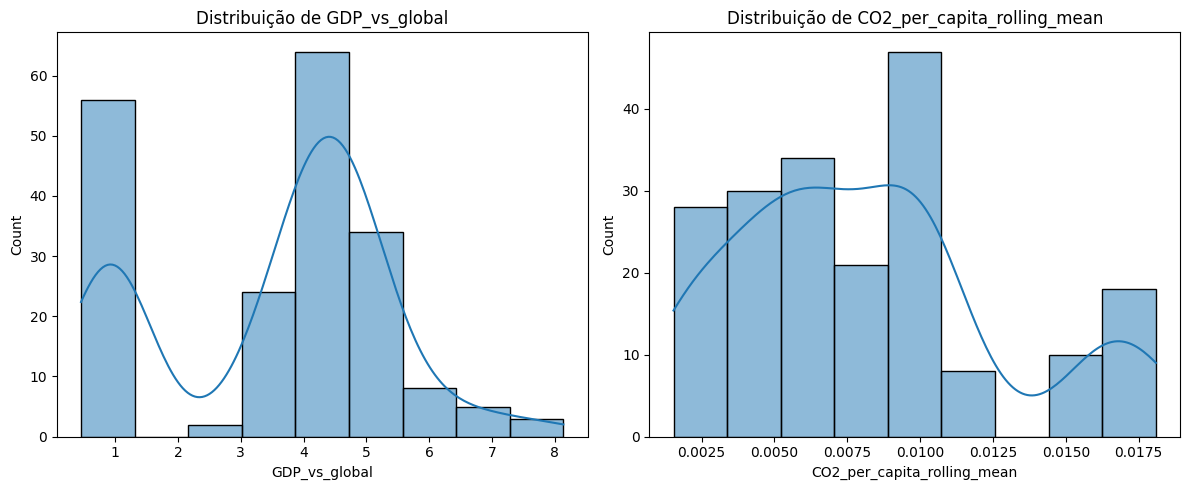

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Supondo que df_final já esteja carregado e processado até a seleção de features.
# Se necessário, recarregue df_final e execute os passos de pré-processamento/engenharia de features.
# Exemplo de como df_final seria para esta etapa (após todas as limpezas e engenharia de features):
# df_final = pd.read_csv("seu_df_final_processado.csv") # Se você salvou
# Ou execute os blocos de código anteriores para recriá-lo em memória

# Definir X e y (como na última seleção de features)
y = df_final['Temp_SMA']
X = df_final[['GDP_vs_global', 'CO2_per_capita_rolling_mean', 'Country', 'Year']]

print("--- Visualizando Relações para Linearização ---")

# Criar scatter plots das features numéricas vs. Temp_SMA
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Relação entre Features Numéricas e Crescimento de Temperatura (Temp_SMA)', fontsize=16)

sns.scatterplot(data=df_final, x='GDP_vs_global', y='Temp_SMA', ax=axes[0])
axes[0].set_title('GDP_vs_global vs. Temp_SMA')
axes[0].set_xlabel('PIB per capita vs. Média Global')
axes[0].set_ylabel('Crescimento da Temperatura Média (SMA)')
axes[0].grid(True, linestyle='--', alpha=0.7)

sns.scatterplot(data=df_final, x='CO2_per_capita_rolling_mean', y='Temp_SMA', ax=axes[1])
axes[1].set_title('CO2_per_capita_rolling_mean vs. Temp_SMA')
axes[1].set_xlabel('CO2 per capita (Média Móvel)')
axes[1].set_ylabel('Crescimento da Temperatura Média (SMA)')
axes[1].grid(True, linestyle='--', alpha=0.7)

sns.scatterplot(data=df_final, x='Year', y='Temp_SMA', ax=axes[2])
axes[2].set_title('Year vs. Temp_SMA')
axes[2].set_xlabel('Ano')
axes[2].set_ylabel('Crescimento da Temperatura Média (SMA)')
axes[2].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("\n--- Verificando a distribuição das features para transformações ---")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df_final['GDP_vs_global'], kde=True, ax=axes[0])
axes[0].set_title('Distribuição de GDP_vs_global')
sns.histplot(df_final['CO2_per_capita_rolling_mean'], kde=True, ax=axes[1])
axes[1].set_title('Distribuição de CO2_per_capita_rolling_mean')
plt.tight_layout()
plt.show()

Isso sugere que, para este dataset e variável alvo, as relações entre as features e o crescimento da temperatura média não foram mais bem capturadas por uma linearização via logaritmo. É provável que as complexidades e não-linearidades do problema sejam melhor abordadas por modelos mais avançados, como o XGBoost Otimizado, que continua sendo o modelo de melhor desempenho com um R² significativamente maior.

# Realizar uma previsão para 2015 com dados até 2010.

--- Preparando dados para previsão com pipeline salvo ---
Dados para o ano 2015: 7 amostras
Pipeline carregado com sucesso!

Resultados da Previsão para o ano 2015:
RMSE: 0.0321
R²: 0.9902

Detalhe das Previsões para 2015 por País:
   Country  Year  Actual_Temp_SMA  Predicted_Temp_SMA
0   Brazil  2015         1.359843            1.344988
1   Canada  2015         0.926706            0.948988
2   France  2015         1.491882            1.429891
3  Germany  2015         1.689000            1.684255
4    Italy  2015         1.518824            1.565815
5    Japan  2015         0.706255            0.687794
6    World  2015         1.198333            1.208252


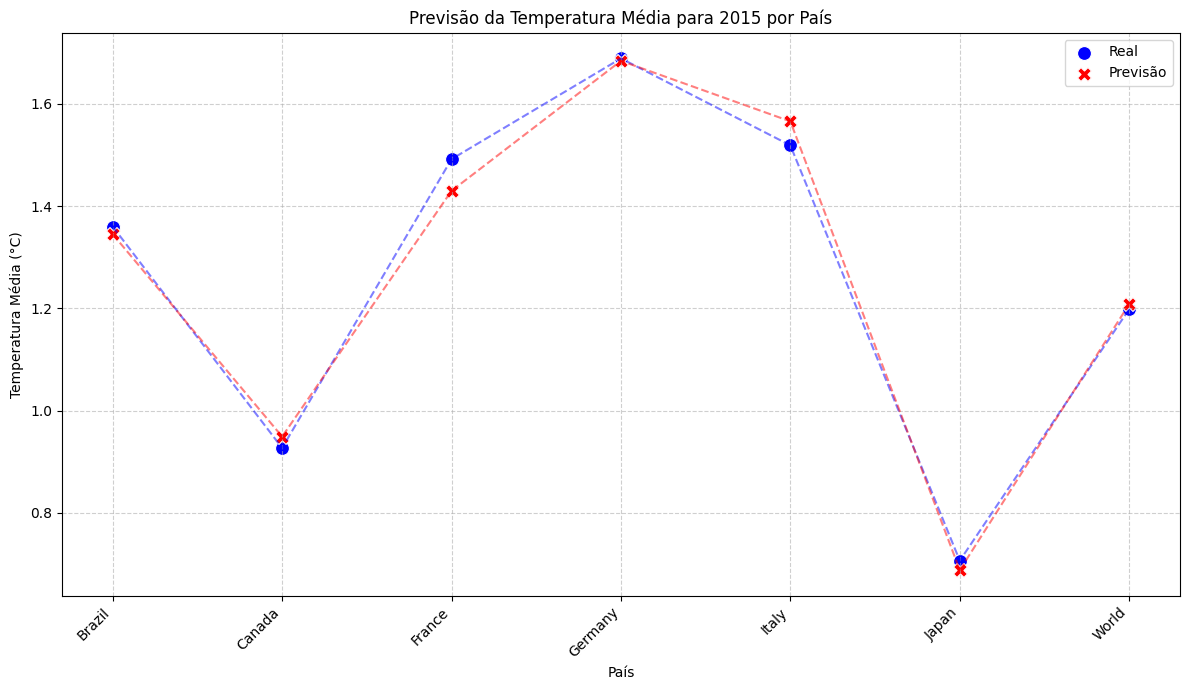

In [45]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score

print("--- Preparando dados para previsão com pipeline salvo ---")

# Ordenar e criar lag
df_final = df_final.sort_values(by=['Country', 'Year'])
df_final['Temp_SMA_lag1'] = df_final.groupby('Country')['Temp_SMA'].shift(1)
df_final.dropna(subset=['Temp_SMA_lag1'], inplace=True)

# Selecionar features e alvo
y = df_final['Temp_SMA']
X = df_final[['GDP_vs_global', 'CO2_per_capita_rolling_mean', 'Country', 'Year', 'Temp_SMA_lag1']]

# Definir ano para teste
test_year_predict = 2015

X_test_2015_df = X[X['Year'] == test_year_predict]
y_test_2015 = y[X['Year'] == test_year_predict]

if X_test_2015_df.empty:
    print(f"Erro: Não há dados para o ano {test_year_predict} para teste.")
else:
    print(f"Dados para o ano {test_year_predict}: {X_test_2015_df.shape[0]} amostras")

    # Carregar pipeline salvo
    try:
        pipeline = joblib.load('pipeline_xgb_otimizado.joblib')
        print("Pipeline carregado com sucesso!")
    except FileNotFoundError:
        raise FileNotFoundError("Arquivo pipeline_xgb_otimizado.joblib não encontrado. Treine e salve o modelo antes.")

    # Fazer previsão usando o pipeline (pré-processamento + modelo)
    y_pred_2015 = pipeline.predict(X_test_2015_df)

    # Avaliar desempenho
    rmse_2015 = np.sqrt(mean_squared_error(y_test_2015, y_pred_2015))
    r2_2015 = r2_score(y_test_2015, y_pred_2015)

    print(f"\nResultados da Previsão para o ano {test_year_predict}:")
    print(f"RMSE: {rmse_2015:.4f}")
    print(f"R²: {r2_2015:.4f}")

    # Criar DataFrame para visualizar resultados
    results_2015 = pd.DataFrame({
        'Country': X_test_2015_df['Country'],
        'Year': X_test_2015_df['Year'],
        'Actual_Temp_SMA': y_test_2015,
        'Predicted_Temp_SMA': y_pred_2015
    }).reset_index(drop=True)

    print(f"\nDetalhe das Previsões para {test_year_predict} por País:")
    print(results_2015)

    # Plotar
    plt.figure(figsize=(12, 7))
    sns.scatterplot(data=results_2015, x='Country', y='Actual_Temp_SMA', label='Real', color='blue', s=100)
    sns.scatterplot(data=results_2015, x='Country', y='Predicted_Temp_SMA', label='Previsão', color='red', marker='X', s=100)
    plt.plot(results_2015['Country'], results_2015['Actual_Temp_SMA'], color='blue', linestyle='--', alpha=0.5)
    plt.plot(results_2015['Country'], results_2015['Predicted_Temp_SMA'], color='red', linestyle='--', alpha=0.5)
    plt.title(f'Previsão da Temperatura Média para {test_year_predict} por País')
    plt.xlabel('País')
    plt.ylabel('Temperatura Média (°C)')
    plt.xticks(rotation=45, ha='right')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


## Previsão dos anos 2025, 2030, 2050 e 2070

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_19780\3291286101.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df_final.groupby('Country').apply(
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_19780\3291286101.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df_final.groupby('Country').apply(


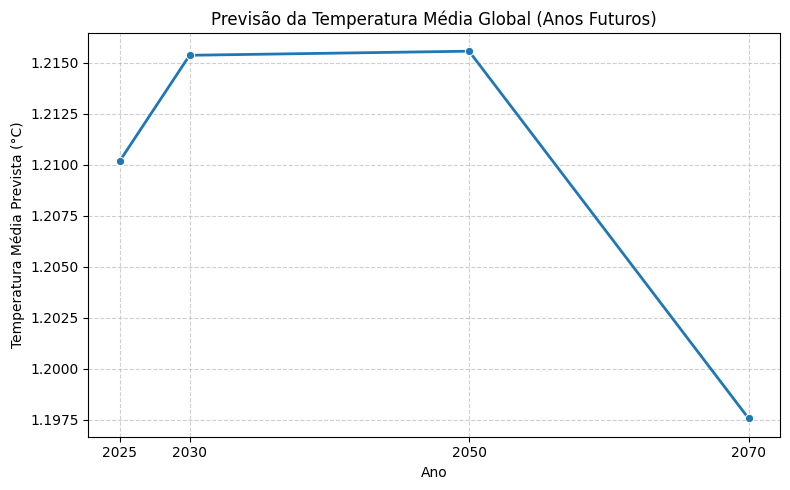

In [ ]:
# Carregar pipeline salvo (pré-processamento + modelo)
pipeline = joblib.load('pipeline_xgb_otimizado.joblib')

anos_futuros = [2025, 2030, 2040, 2050]
paises = df_final['Country'].unique()
ultimo_ano = df_final['Year'].max()

# Histórico inicial
df_hist = df_final[['Country', 'Year', 'Temp_SMA', 'GDP_vs_global', 'CO2_per_capita_rolling_mean']].copy()

# Tendências lineares por país
def tendencia(col):
    return df_final.groupby('Country').apply(
        lambda g: np.polyfit(g['Year'], g[col], 1)[0] if len(g) > 1 else 0
    ).to_dict()

tend_gdp = tendencia('GDP_vs_global')
tend_co2 = tendencia('CO2_per_capita_rolling_mean')

# Últimos valores por país
def ultimo_valor(col):
    return df_final[df_final['Year'] == ultimo_ano].set_index('Country')[col].to_dict()

gdp_ultimo = ultimo_valor('GDP_vs_global')
co2_ultimo = ultimo_valor('CO2_per_capita_rolling_mean')

previsoes_futuras = []

for ano in anos_futuros:
    registros = []
    for pais in paises:
        temp_lag1 = df_hist[(df_hist['Country'] == pais) & (df_hist['Year'] == ano - 1)]['Temp_SMA']
        temp_lag1 = temp_lag1.values[0] if not temp_lag1.empty else df_final['Temp_SMA'].mean()

        gdp_base = gdp_ultimo.get(pais, df_final['GDP_vs_global'].mean())
        co2_base = co2_ultimo.get(pais, df_final['CO2_per_capita_rolling_mean'].mean())

        gdp_proj = gdp_base + tend_gdp.get(pais, 0) * (ano - ultimo_ano)
        co2_proj = co2_base + tend_co2.get(pais, 0) * (ano - ultimo_ano)

        registros.append({
            'Country': pais,
            'Year': ano,
            'GDP_vs_global': np.clip(gdp_proj, -2, 2),
            'CO2_per_capita_rolling_mean': np.clip(co2_proj, 0, 100),
            'Temp_SMA_lag1': temp_lag1
        })

    df_ano = pd.DataFrame(registros)
    
    # Previsão usando pipeline completo (pré-processamento + modelo)
    y_pred = pipeline.predict(df_ano)
    df_ano['Predicted_Temp_SMA'] = y_pred

    previsoes_futuras.append(df_ano)

    # Atualizar histórico para próximo ano
    df_novo = df_ano[['Country', 'Year', 'Predicted_Temp_SMA', 'GDP_vs_global', 'CO2_per_capita_rolling_mean']].rename(
        columns={'Predicted_Temp_SMA': 'Temp_SMA'}
    )
    df_hist = pd.concat([df_hist, df_novo], ignore_index=True)

df_resultado = pd.concat(previsoes_futuras)
media_global = df_resultado.groupby('Year')['Predicted_Temp_SMA'].mean().reset_index()

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.lineplot(data=media_global, x='Year', y='Predicted_Temp_SMA', marker='o', linewidth=2)
plt.title('Previsão da Temperatura Média Global (Anos Futuros)')
plt.xlabel('Ano')
plt.ylabel('Temperatura Média Prevista (°C)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(anos_futuros)
plt.tight_layout()
plt.show()
